In [1]:
# Cell 1 — Install required libraries

!pip install -q pandas numpy scikit-learn openpyxl matplotlib seaborn
!pip install -q xgboost lightgbm catboost shap imbalanced-learn
!pip install -q tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.1/727.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.8/240.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
# Cell 2 — Import libraries

import os
import getpass
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

import shap
from tabpfn import TabPFNClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DEVICE = "cuda" if os.system("nvidia-smi > /dev/null 2>&1") == 0 else "cpu"

OUTPUT_DIR = "telco_churn_results"
FIGURE_DIR = f"{OUTPUT_DIR}/figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Libraries imported successfully.")
print("Device:", DEVICE)
print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIGURE_DIR)

Libraries imported successfully.
Device: cuda
Output directory: telco_churn_results
Figure directory: telco_churn_results/figures


In [3]:
# Cell 3 — Set TabPFN access token

# Get the TabPFN/Prior Labs access token from:
# https://ux.priorlabs.ai
# Account → Access Tokens
#
# Do not hard-code the token if the notebook will be shared publicly.

if "TABPFN_TOKEN" not in os.environ:
    os.environ["TABPFN_TOKEN"] = getpass.getpass("Enter your TabPFN/Prior Labs access token: ")

print("TabPFN token set for this session.")

Enter your TabPFN/Prior Labs access token: ··········
TabPFN token set for this session.


In [4]:
# Cell 4 — Load dataset

DATA_PATH = "Telco_customer_churn.xlsx"

df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
# Cell 5 — Inspect dataset structure and target distribution

print("Dataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nTarget distribution:")
display(df["Churn Value"].value_counts())

print("\nTarget distribution (%):")
display(df["Churn Value"].value_counts(normalize=True) * 100)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Int

,0
Churn Reason,5174
CustomerID,0
Count,0
State,0
Country,0
Zip Code,0
Lat Long,0
Latitude,0
City,0
Gender,0



Target distribution:


,count
Churn Value,
0,5174
1,1869



Target distribution (%):


,proportion
Churn Value,
0,73.463013
1,26.536987


In [6]:
# Cell 6 — Convert Total Charges to numeric and handle missing values

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

print("Missing Total Charges before imputation:", df["Total Charges"].isnull().sum())

df["Total Charges"] = df["Total Charges"].fillna(0)

print("Missing Total Charges after imputation:", df["Total Charges"].isnull().sum())

Missing Total Charges before imputation: 11
Missing Total Charges after imputation: 0


In [7]:
# Cell 7 — Preserve target and analysis columns

target_col = "Churn Value"
cltv_col = "CLTV"

y = df[target_col].copy()
cltv = df[cltv_col].copy()

protected_gender = df["Gender"].copy()
protected_senior = df["Senior Citizen"].copy()

# Churn Reason is not used for training.
churn_reason = df["Churn Reason"].copy()

print("Target, CLTV, protected attributes, and churn reason preserved.")

Target, CLTV, protected attributes, and churn reason preserved.


In [8]:
# Cell 8 — Remove leakage and non-predictive columns

drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "Lat Long",
    "Zip Code",
    "Latitude",
    "Longitude"
]

drop_cols_existing = [col for col in drop_cols if col in df.columns]

X_raw = df.drop(columns=drop_cols_existing)

print("Dropped columns:", drop_cols_existing)
print("Feature shape:", X_raw.shape)

display(X_raw.head())

Dropped columns: ['CustomerID', 'Count', 'Country', 'State', 'Churn Label', 'Churn Value', 'Churn Score', 'Churn Reason', 'Lat Long', 'Zip Code', 'Latitude', 'Longitude']
Feature shape: (7043, 21)


,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
0,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,3239
1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,2701
2,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,5372
3,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,5003
4,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,5340


In [9]:
# Cell 9 — Create business-oriented features

X = X_raw.copy()

# Tenure group
X["TenureGroup"] = pd.cut(
    X["Tenure Months"],
    bins=[-1, 12, 36, np.inf],
    labels=["New", "Mid", "Long"]
).astype(str)

# Average spending ratio
X["AvgSpendRatio"] = X["Total Charges"] / (X["Tenure Months"] + 1)

# Service count
service_cols = [
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

existing_service_cols = [col for col in service_cols if col in X.columns]

X["ServiceCount"] = X[existing_service_cols].apply(
    lambda row: (row.astype(str).str.lower() == "yes").sum(),
    axis=1
)

# Contract risk
X["ContractRisk"] = (X["Contract"].astype(str) == "Month-to-month").astype(int)

# Support risk
X["SupportRisk"] = (
    (X["Online Security"].astype(str) == "No") &
    (X["Tech Support"].astype(str) == "No")
).astype(int)

# Automatic payment flag
X["AutoPayment"] = X["Payment Method"].astype(str).isin(
    ["Bank transfer (automatic)", "Credit card (automatic)"]
).astype(int)

print("Feature engineering completed.")
print("Final feature shape:", X.shape)

display(X.head())

Feature engineering completed.
Final feature shape: (7043, 27)


,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Payment Method,Monthly Charges,Total Charges,CLTV,TenureGroup,AvgSpendRatio,ServiceCount,ContractRisk,SupportRisk,AutoPayment
0,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,3239,New,36.050000,3,1,0,0
1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,2701,New,50.550000,1,1,1,0
2,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,Electronic check,99.65,820.50,5372,New,91.166667,5,1,1,0
3,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Electronic check,104.80,3046.05,5003,Mid,105.036207,6,1,0,0
4,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,Bank transfer (automatic),103.70,5036.30,5340,Long,100.726000,6,1,1,1


In [10]:
# Cell 10 — Identify categorical and numerical columns

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical features:", len(categorical_cols))
print(categorical_cols)

print("\nNumerical features:", len(numerical_cols))
print(numerical_cols)

Categorical features: 18
['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'TenureGroup']

Numerical features: 9
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'AvgSpendRatio', 'ServiceCount', 'ContractRisk', 'SupportRisk', 'AutoPayment']


In [11]:
# Cell 11 — Create train, validation, and test splits

X_train_full, X_test, y_train_full, y_test, cltv_train_full, cltv_test, gender_train_full, gender_test, senior_train_full, senior_test, reason_train_full, reason_test = train_test_split(
    X,
    y,
    cltv,
    protected_gender,
    protected_senior,
    churn_reason,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val, cltv_train, cltv_val, gender_train, gender_val, senior_train, senior_val, reason_train, reason_val = train_test_split(
    X_train_full,
    y_train_full,
    cltv_train_full,
    gender_train_full,
    senior_train_full,
    reason_train_full,
    test_size=0.17647,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
display(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
display(y_val.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True) * 100)

Train shape: (4929, 27)
Validation shape: (1057, 27)
Test shape: (1057, 27)

Train target distribution:


,proportion
Churn Value,
0,73.463177
1,26.536823



Validation target distribution:


,proportion
Churn Value,
0,73.415326
1,26.584674



Test target distribution:


,proportion
Churn Value,
0,73.509934
1,26.490066


In [12]:
# Cell 12 — Create CLTV-based sample weights

def create_cltv_weights(y_values, cltv_values, alpha=2.0):
    """
    Create higher weights for high-CLTV churned customers.
    """
    y_values = np.array(y_values)
    cltv_values = pd.Series(cltv_values).astype(float)

    cltv_min = cltv_values.min()
    cltv_max = cltv_values.max()

    if cltv_max == cltv_min:
        cltv_norm = np.zeros(len(cltv_values))
    else:
        cltv_norm = (cltv_values - cltv_min) / (cltv_max - cltv_min)

    weights = np.where(
        y_values == 1,
        1 + alpha * cltv_norm,
        1
    )

    return np.array(weights, dtype=float)

alpha = 2.0

train_weights = create_cltv_weights(y_train, cltv_train, alpha=alpha)

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("Scale pos weight:", round(scale_pos_weight, 4))
print("Sample weight range:", train_weights.min(), "to", train_weights.max())

Negative samples: 3621
Positive samples: 1308
Scale pos weight: 2.7683
Sample weight range: 1.0 to 2.9951024042742653


In [13]:
# Cell 13 — Create preprocessing pipelines

def make_onehot_encoder():
    """
    Create OneHotEncoder compatible with different sklearn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# XGBoost and LightGBM preprocessing
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", make_onehot_encoder(), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ],
    remainder="drop"
)

# TabPFN preprocessing
tabpfn_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ],
    remainder="drop"
)

print("Preprocessors created.")

Preprocessors created.


In [14]:
# Cell 14 — Prepare encoded data for XGBoost and LightGBM

X_train_tree = tree_preprocessor.fit_transform(X_train)
X_val_tree = tree_preprocessor.transform(X_val)
X_test_tree = tree_preprocessor.transform(X_test)

cat_feature_names = tree_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
tree_feature_names = list(cat_feature_names) + numerical_cols

X_train_tree = pd.DataFrame(X_train_tree, columns=tree_feature_names, index=X_train.index)
X_val_tree = pd.DataFrame(X_val_tree, columns=tree_feature_names, index=X_val.index)
X_test_tree = pd.DataFrame(X_test_tree, columns=tree_feature_names, index=X_test.index)

print("Tree-based encoded data prepared.")
print("Encoded train shape:", X_train_tree.shape)

Tree-based encoded data prepared.
Encoded train shape: (4929, 1178)


In [15]:
# Cell 15 — Prepare raw categorical data for CatBoost

X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

for col in categorical_cols:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_val_cat[col] = X_val_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

cat_features_indices = [X_train_cat.columns.get_loc(col) for col in categorical_cols]

print("CatBoost data prepared.")
print("Number of categorical features:", len(cat_features_indices))

CatBoost data prepared.
Number of categorical features: 18


In [16]:
# Cell 16 — Prepare encoded and scaled data for TabPFN

X_train_tabpfn = tabpfn_preprocessor.fit_transform(X_train)
X_val_tabpfn = tabpfn_preprocessor.transform(X_val)
X_test_tabpfn = tabpfn_preprocessor.transform(X_test)

tabpfn_feature_names = categorical_cols + numerical_cols

print("TabPFN data prepared.")
print("TabPFN train shape:", X_train_tabpfn.shape)

TabPFN data prepared.
TabPFN train shape: (4929, 27)


In [17]:
# Cell 17 — Train XGBoost model

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train_tree,
    y_train,
    sample_weight=train_weights
)

xgb_val_probs = xgb_model.predict_proba(X_val_tree)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test_tree)[:, 1]

print("XGBoost training completed.")

XGBoost training completed.


In [18]:
# Cell 18 — Train LightGBM model

lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lgbm_model.fit(
    X_train_tree,
    y_train,
    sample_weight=train_weights
)

lgbm_val_probs = lgbm_model.predict_proba(X_val_tree)[:, 1]
lgbm_test_probs = lgbm_model.predict_proba(X_test_tree)[:, 1]

print("LightGBM training completed.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1308, number of negative: 3621
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1234
[LightGBM] [Info] Number of data points in the train set: 4929, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.662226 -> initscore=0.673228
[LightGBM] [Info] Start training from score 0.673228
LightGBM training completed.


In [19]:
# Cell 19 — Train CatBoost model

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1, scale_pos_weight],
    random_seed=RANDOM_STATE,
    verbose=100
)

cat_model.fit(
    X_train_cat,
    y_train,
    cat_features=cat_features_indices,
    sample_weight=train_weights,
    eval_set=(X_val_cat, y_val),
    use_best_model=True
)

cat_val_probs = cat_model.predict_proba(X_val_cat)[:, 1]
cat_test_probs = cat_model.predict_proba(X_test_cat)[:, 1]

print("CatBoost training completed.")

0:	test: 0.7815332	best: 0.7815332 (0)	total: 66.5ms	remaining: 33.2s
100:	test: 0.8458401	best: 0.8458722 (98)	total: 1.39s	remaining: 5.49s
200:	test: 0.8498230	best: 0.8498230 (200)	total: 2.77s	remaining: 4.12s
300:	test: 0.8507723	best: 0.8513822 (290)	total: 4.46s	remaining: 2.95s
400:	test: 0.8525654	best: 0.8526938 (386)	total: 6.82s	remaining: 1.68s
499:	test: 0.8515611	best: 0.8527259 (404)	total: 8.29s	remaining: 0us

bestTest = 0.8527259053
bestIteration = 404

Shrink model to first 405 iterations.
CatBoost training completed.


In [20]:
# Cell 20 — Train TabPFN model

# TabPFN is used as an advanced tabular foundation model.
# Access token source: https://ux.priorlabs.ai → Account → Access Tokens

tabpfn_model = TabPFNClassifier(device=DEVICE)

tabpfn_model.fit(X_train_tabpfn, y_train)

tabpfn_val_probs = tabpfn_model.predict_proba(X_val_tabpfn)[:, 1]
tabpfn_test_probs = tabpfn_model.predict_proba(X_test_tabpfn)[:, 1]

print("TabPFN training completed.")

tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

TabPFN training completed.


In [21]:
# Cell 21 — Store validation and test probabilities

val_prob_dict = {
    "XGBoost": xgb_val_probs,
    "LightGBM": lgbm_val_probs,
    "CatBoost": cat_val_probs,
    "TabPFN": tabpfn_val_probs
}

test_prob_dict = {
    "XGBoost": xgb_test_probs,
    "LightGBM": lgbm_test_probs,
    "CatBoost": cat_test_probs,
    "TabPFN": tabpfn_test_probs
}

print("Models included:", list(test_prob_dict.keys()))

Models included: ['XGBoost', 'LightGBM', 'CatBoost', 'TabPFN']


In [22]:
# Cell 22 — Define classification evaluation function

def evaluate_classification(y_true, y_prob, threshold=0.5):
    """
    Calculate standard classification metrics.
    """
    y_pred = (np.array(y_prob) >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Brier_Score": brier_score_loss(y_true, y_prob)
    }

In [23]:
# Cell 23 — Define profit evaluation functions

def calculate_total_profit(y_true, y_prob, cltv_values, threshold=0.5, retention_rate=0.6, campaign_cost=50):
    """
    Calculate realized profit for targeted customers.
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    cltv_values = np.array(cltv_values)

    targeted = y_prob >= threshold

    profit = np.sum(
        (y_true[targeted] * cltv_values[targeted] * retention_rate) - campaign_cost
    )

    return profit


def calculate_profit_at_top_k(y_true, y_prob, cltv_values, top_k_percent=0.20, retention_rate=0.6, campaign_cost=50):
    """
    Calculate realized profit for top-k highest-risk customers.
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    cltv_values = np.array(cltv_values)

    n_target = int(len(y_prob) * top_k_percent)
    top_indices = np.argsort(y_prob)[::-1][:n_target]

    profit = np.sum(
        (y_true[top_indices] * cltv_values[top_indices] * retention_rate) - campaign_cost
    )

    return profit


def calculate_cltv_weighted_recall(y_true, y_prob, cltv_values, threshold=0.5):
    """
    Calculate CLTV-weighted recall for churned customers.
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    cltv_values = np.array(cltv_values)

    y_pred = (y_prob >= threshold).astype(int)

    total_churn_cltv = np.sum(cltv_values[y_true == 1])
    captured_churn_cltv = np.sum(cltv_values[(y_true == 1) & (y_pred == 1)])

    if total_churn_cltv == 0:
        return 0

    return captured_churn_cltv / total_churn_cltv


def calculate_expected_profit_targeting(y_prob, cltv_values, retention_rate=0.6, campaign_cost=50):
    """
    Identify customers with positive expected retention profit.
    """
    y_prob = np.array(y_prob)
    cltv_values = np.array(cltv_values)

    expected_profit = (y_prob * cltv_values * retention_rate) - campaign_cost
    target_mask = expected_profit > 0

    return expected_profit, target_mask


def find_best_profit_threshold(y_true, y_prob, cltv_values, retention_rate=0.6, campaign_cost=50):
    """
    Find threshold that maximizes validation profit.
    """
    thresholds = np.arange(0.4, 0.6, 0.01)

    best_threshold = 0.5
    best_profit = -np.inf
    profit_curve = []

    for threshold in thresholds:
        profit = calculate_total_profit(
            y_true,
            y_prob,
            cltv_values,
            threshold=threshold,
            retention_rate=retention_rate,
            campaign_cost=campaign_cost
        )

        profit_curve.append({
            "Threshold": threshold,
            "Profit": profit
        })

        if profit > best_profit:
            best_profit = profit
            best_threshold = threshold

    return best_threshold, best_profit, pd.DataFrame(profit_curve)

In [24]:
# Cell 24 — Define fairness evaluation functions

def demographic_parity_gap(y_pred, protected_attr):
    """
    Calculate demographic parity gap.
    """
    temp_df = pd.DataFrame({
        "prediction": y_pred,
        "group": protected_attr
    })

    rates = temp_df.groupby("group")["prediction"].mean()

    if len(rates) < 2:
        return 0

    return rates.max() - rates.min()


def equal_opportunity_gap(y_true, y_pred, protected_attr):
    """
    Calculate equal opportunity gap using TPR.
    """
    temp_df = pd.DataFrame({
        "true": y_true,
        "prediction": y_pred,
        "group": protected_attr
    })

    tpr_values = []

    for group in temp_df["group"].unique():
        group_df = temp_df[temp_df["group"] == group]

        if (group_df["true"] == 1).sum() == 0:
            continue

        tpr = recall_score(
            group_df["true"],
            group_df["prediction"],
            zero_division=0
        )

        tpr_values.append(tpr)

    if len(tpr_values) < 2:
        return 0

    return max(tpr_values) - min(tpr_values)


def false_positive_rate_gap(y_true, y_pred, protected_attr):
    """
    Calculate group-wise false positive rate gap.
    """
    temp_df = pd.DataFrame({
        "true": y_true,
        "prediction": y_pred,
        "group": protected_attr
    })

    fpr_values = []

    for group in temp_df["group"].unique():
        group_df = temp_df[temp_df["group"] == group]

        tn, fp, fn, tp = confusion_matrix(
            group_df["true"],
            group_df["prediction"],
            labels=[0, 1]
        ).ravel()

        if (fp + tn) == 0:
            continue

        fpr = fp / (fp + tn)
        fpr_values.append(fpr)

    if len(fpr_values) < 2:
        return 0

    return max(fpr_values) - min(fpr_values)


def evaluate_fairness(y_true, y_prob, protected_attr, threshold):
    """
    Calculate fairness gaps for one protected attribute.
    """
    y_pred = (np.array(y_prob) >= threshold).astype(int)

    dp_gap = demographic_parity_gap(y_pred, protected_attr)
    eo_gap = equal_opportunity_gap(y_true, y_pred, protected_attr)
    fpr_gap = false_positive_rate_gap(y_true, y_pred, protected_attr)

    return dp_gap, eo_gap, fpr_gap

In [25]:
# Cell 25 — Evaluate all models at default threshold 0.5

default_results = []

for model_name, probs in test_prob_dict.items():
    metrics = evaluate_classification(y_test, probs, threshold=0.5)
    metrics["Model"] = model_name
    metrics["Threshold"] = 0.5
    default_results.append(metrics)

default_results_df = pd.DataFrame(default_results)

default_results_df = default_results_df[
    ["Model", "Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "Brier_Score"]
]

display(default_results_df.sort_values(by="F1", ascending=False))

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score
1,LightGBM,0.5,0.771050,0.549479,0.753571,0.635542,0.847077,0.638988,0.163924
0,XGBoost,0.5,0.725639,0.489960,0.871429,0.627249,0.850602,0.652490,0.186530
2,CatBoost,0.5,0.709555,0.474480,0.896429,0.620519,0.859487,0.654828,0.191732
3,TabPFN,0.5,0.811731,0.670886,0.567857,0.615087,0.867751,0.690185,0.127980


In [26]:
# Cell 26 — Evaluate profit metrics at threshold 0.5

retention_rate = 0.6
campaign_cost = 50

default_profit_results = []

for model_name, probs in test_prob_dict.items():
    total_profit = calculate_total_profit(
        y_test,
        probs,
        cltv_test,
        threshold=0.5,
        retention_rate=retention_rate,
        campaign_cost=campaign_cost
    )

    profit_top_20 = calculate_profit_at_top_k(
        y_test,
        probs,
        cltv_test,
        top_k_percent=0.20,
        retention_rate=retention_rate,
        campaign_cost=campaign_cost
    )

    cltv_recall = calculate_cltv_weighted_recall(
        y_test,
        probs,
        cltv_test,
        threshold=0.5
    )

    default_profit_results.append({
        "Model": model_name,
        "Threshold": 0.5,
        "Total_Profit": total_profit,
        "Profit_Top_20%": profit_top_20,
        "CLTV_Weighted_Recall": cltv_recall
    })

default_profit_df = pd.DataFrame(default_profit_results)

display(default_profit_df.sort_values(by="Total_Profit", ascending=False))

,Model,Threshold,Total_Profit,Profit_Top_20%,CLTV_Weighted_Recall
2,CatBoost,0.5,582215.8,324791.2,0.896043
0,XGBoost,0.5,564883.8,325957.0,0.868246
1,LightGBM,0.5,488114.4,327043.0,0.746840
3,TabPFN,0.5,355564.8,329747.8,0.540887


In [27]:
# Cell 27 — Optimize threshold using validation profit

best_thresholds = {}
validation_profit_curves = {}

for model_name, probs in val_prob_dict.items():
    best_t, best_profit, curve_df = find_best_profit_threshold(
        y_val,
        probs,
        cltv_val,
        retention_rate=retention_rate,
        campaign_cost=campaign_cost
    )

    best_thresholds[model_name] = best_t
    validation_profit_curves[model_name] = curve_df

    print(f"{model_name}: Best threshold = {best_t:.2f}, Validation profit = {best_profit:.2f}")

XGBoost: Best threshold = 0.40, Validation profit = 590182.80
LightGBM: Best threshold = 0.41, Validation profit = 514172.80
CatBoost: Best threshold = 0.40, Validation profit = 614025.80
TabPFN: Best threshold = 0.40, Validation profit = 405819.80


In [28]:
# Cell 28 — Evaluate test results using validation-optimized thresholds

optimized_classification_results = []
optimized_profit_results = []

for model_name, probs in test_prob_dict.items():
    threshold = best_thresholds[model_name]

    class_metrics = evaluate_classification(y_test, probs, threshold=threshold)
    class_metrics["Model"] = model_name
    class_metrics["Best_Threshold"] = threshold
    optimized_classification_results.append(class_metrics)

    total_profit = calculate_total_profit(
        y_test,
        probs,
        cltv_test,
        threshold=threshold,
        retention_rate=retention_rate,
        campaign_cost=campaign_cost
    )

    profit_top_20 = calculate_profit_at_top_k(
        y_test,
        probs,
        cltv_test,
        top_k_percent=0.20,
        retention_rate=retention_rate,
        campaign_cost=campaign_cost
    )

    cltv_recall = calculate_cltv_weighted_recall(
        y_test,
        probs,
        cltv_test,
        threshold=threshold
    )

    optimized_profit_results.append({
        "Model": model_name,
        "Best_Threshold": threshold,
        "Total_Profit": total_profit,
        "Profit_Top_20%": profit_top_20,
        "CLTV_Weighted_Recall": cltv_recall
    })

optimized_classification_df = pd.DataFrame(optimized_classification_results)
optimized_profit_df = pd.DataFrame(optimized_profit_results)

optimized_classification_df = optimized_classification_df[
    ["Model", "Best_Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "Brier_Score"]
]

display(optimized_classification_df.sort_values(by="F1", ascending=False))
display(optimized_profit_df.sort_values(by="Total_Profit", ascending=False))

,Model,Best_Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score
3,TabPFN,0.40,0.804163,0.621262,0.667857,0.643718,0.867751,0.690185,0.127980
1,LightGBM,0.41,0.758751,0.529691,0.796429,0.636234,0.847077,0.638988,0.163924
0,XGBoost,0.40,0.697256,0.463768,0.914286,0.615385,0.850602,0.652490,0.186530
2,CatBoost,0.40,0.674551,0.445017,0.925000,0.600928,0.859487,0.654828,0.191732


,Model,Best_Threshold,Total_Profit,Profit_Top_20%,CLTV_Weighted_Recall
2,CatBoost,0.40,599968.8,324791.2,0.926080
0,XGBoost,0.40,592980.6,325957.0,0.913584
1,LightGBM,0.41,513716.2,327043.0,0.787253
3,TabPFN,0.40,422724.4,329747.8,0.644467


In [29]:
# Cell 29 — Display confusion matrices

for model_name, probs in test_prob_dict.items():
    threshold = best_thresholds[model_name]
    y_pred = (probs >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    print("=" * 60)
    print(f"Model: {model_name}")
    print(f"Threshold: {threshold:.2f}")
    print(cm)

Model: XGBoost
Threshold: 0.40
[[481 296]
 [ 24 256]]
Model: LightGBM
Threshold: 0.41
[[579 198]
 [ 57 223]]
Model: CatBoost
Threshold: 0.40
[[454 323]
 [ 21 259]]
Model: TabPFN
Threshold: 0.40
[[663 114]
 [ 93 187]]


In [30]:
# Cell 30 — Display classification reports

for model_name, probs in test_prob_dict.items():
    threshold = best_thresholds[model_name]
    y_pred = (probs >= threshold).astype(int)

    print("=" * 70)
    print(f"Classification Report: {model_name}")
    print(f"Threshold: {threshold:.2f}")
    print(classification_report(y_test, y_pred, zero_division=0))

Classification Report: XGBoost
Threshold: 0.40
              precision    recall  f1-score   support

           0       0.95      0.62      0.75       777
           1       0.46      0.91      0.62       280

    accuracy                           0.70      1057
   macro avg       0.71      0.77      0.68      1057
weighted avg       0.82      0.70      0.71      1057

Classification Report: LightGBM
Threshold: 0.41
              precision    recall  f1-score   support

           0       0.91      0.75      0.82       777
           1       0.53      0.80      0.64       280

    accuracy                           0.76      1057
   macro avg       0.72      0.77      0.73      1057
weighted avg       0.81      0.76      0.77      1057

Classification Report: CatBoost
Threshold: 0.40
              precision    recall  f1-score   support

           0       0.96      0.58      0.73       777
           1       0.45      0.93      0.60       280

    accuracy                           

In [31]:
# Cell 31 — 10-fold cross-validation for all four models

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

print("Starting 10-fold cross-validation...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    print(f"\nFold {fold}/10")

    X_cv_train = X.iloc[train_idx].copy()
    X_cv_test = X.iloc[test_idx].copy()

    y_cv_train = y.iloc[train_idx].copy()
    y_cv_test = y.iloc[test_idx].copy()

    cltv_cv_train = cltv.iloc[train_idx].copy()

    # Create CLTV weights inside each fold
    cv_train_weights = create_cltv_weights(
        y_cv_train,
        cltv_cv_train,
        alpha=alpha
    )

    cv_negative = (y_cv_train == 0).sum()
    cv_positive = (y_cv_train == 1).sum()
    cv_scale_pos_weight = cv_negative / cv_positive

    cv_categorical_cols = X_cv_train.select_dtypes(include=["object", "category"]).columns.tolist()
    cv_numerical_cols = X_cv_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

    # Preprocessors
    cv_tree_preprocessor = ColumnTransformer(
        transformers=[
            ("cat", make_onehot_encoder(), cv_categorical_cols),
            ("num", "passthrough", cv_numerical_cols)
        ],
        remainder="drop"
    )

    cv_tabpfn_preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cv_categorical_cols),
            ("num", StandardScaler(), cv_numerical_cols)
        ],
        remainder="drop"
    )

    # XGBoost and LightGBM encoded data
    X_cv_train_tree = cv_tree_preprocessor.fit_transform(X_cv_train)
    X_cv_test_tree = cv_tree_preprocessor.transform(X_cv_test)

    # CatBoost raw categorical data
    X_cv_train_cat = X_cv_train.copy()
    X_cv_test_cat = X_cv_test.copy()

    for col in cv_categorical_cols:
        X_cv_train_cat[col] = X_cv_train_cat[col].astype(str)
        X_cv_test_cat[col] = X_cv_test_cat[col].astype(str)

    cv_cat_features_indices = [
        X_cv_train_cat.columns.get_loc(col)
        for col in cv_categorical_cols
    ]

    # TabPFN encoded data
    X_cv_train_tabpfn = cv_tabpfn_preprocessor.fit_transform(X_cv_train)
    X_cv_test_tabpfn = cv_tabpfn_preprocessor.transform(X_cv_test)

    # -------------------------
    # XGBoost
    # -------------------------
    cv_xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=cv_scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    cv_xgb.fit(
        X_cv_train_tree,
        y_cv_train,
        sample_weight=cv_train_weights
    )

    xgb_probs = cv_xgb.predict_proba(X_cv_test_tree)[:, 1]
    xgb_pred = (xgb_probs >= 0.5).astype(int)

    cv_results.append({
        "Fold": fold,
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_cv_test, xgb_pred),
        "Precision": precision_score(y_cv_test, xgb_pred, zero_division=0),
        "Recall": recall_score(y_cv_test, xgb_pred, zero_division=0),
        "F1": f1_score(y_cv_test, xgb_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_cv_test, xgb_probs),
        "PR_AUC": average_precision_score(y_cv_test, xgb_probs)
    })

    # -------------------------
    # LightGBM
    # -------------------------
    cv_lgbm = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )

    cv_lgbm.fit(
        X_cv_train_tree,
        y_cv_train,
        sample_weight=cv_train_weights
    )

    lgbm_probs = cv_lgbm.predict_proba(X_cv_test_tree)[:, 1]
    lgbm_pred = (lgbm_probs >= 0.5).astype(int)

    cv_results.append({
        "Fold": fold,
        "Model": "LightGBM",
        "Accuracy": accuracy_score(y_cv_test, lgbm_pred),
        "Precision": precision_score(y_cv_test, lgbm_pred, zero_division=0),
        "Recall": recall_score(y_cv_test, lgbm_pred, zero_division=0),
        "F1": f1_score(y_cv_test, lgbm_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_cv_test, lgbm_probs),
        "PR_AUC": average_precision_score(y_cv_test, lgbm_probs)
    })

    # -------------------------
    # CatBoost
    # -------------------------
    cv_cat = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=[1, cv_scale_pos_weight],
        random_seed=RANDOM_STATE,
        verbose=False
    )

    cv_cat.fit(
        X_cv_train_cat,
        y_cv_train,
        cat_features=cv_cat_features_indices,
        sample_weight=cv_train_weights
    )

    cat_probs = cv_cat.predict_proba(X_cv_test_cat)[:, 1]
    cat_pred = (cat_probs >= 0.5).astype(int)

    cv_results.append({
        "Fold": fold,
        "Model": "CatBoost",
        "Accuracy": accuracy_score(y_cv_test, cat_pred),
        "Precision": precision_score(y_cv_test, cat_pred, zero_division=0),
        "Recall": recall_score(y_cv_test, cat_pred, zero_division=0),
        "F1": f1_score(y_cv_test, cat_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_cv_test, cat_probs),
        "PR_AUC": average_precision_score(y_cv_test, cat_probs)
    })

    # -------------------------
    # TabPFN
    # -------------------------
    cv_tabpfn = TabPFNClassifier(device=DEVICE)

    cv_tabpfn.fit(X_cv_train_tabpfn, y_cv_train)

    tabpfn_probs = cv_tabpfn.predict_proba(X_cv_test_tabpfn)[:, 1]
    tabpfn_pred = (tabpfn_probs >= 0.5).astype(int)

    cv_results.append({
        "Fold": fold,
        "Model": "TabPFN",
        "Accuracy": accuracy_score(y_cv_test, tabpfn_pred),
        "Precision": precision_score(y_cv_test, tabpfn_pred, zero_division=0),
        "Recall": recall_score(y_cv_test, tabpfn_pred, zero_division=0),
        "F1": f1_score(y_cv_test, tabpfn_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_cv_test, tabpfn_probs),
        "PR_AUC": average_precision_score(y_cv_test, tabpfn_probs)
    })

cv_results_df = pd.DataFrame(cv_results)

cv_summary_df = (
    cv_results_df
    .groupby("Model")
    .agg({
        "Accuracy": ["mean", "std"],
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "F1": ["mean", "std"],
        "ROC_AUC": ["mean", "std"],
        "PR_AUC": ["mean", "std"]
    })
)

cv_summary_df.columns = [
    "_".join(col).strip()
    for col in cv_summary_df.columns.values
]

cv_summary_df = cv_summary_df.reset_index()

display(cv_results_df)
display(cv_summary_df)

Starting 10-fold cross-validation...

Fold 1/10

Fold 2/10

Fold 3/10

Fold 4/10

Fold 5/10

Fold 6/10

Fold 7/10

Fold 8/10

Fold 9/10

Fold 10/10


,Fold,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,1,XGBoost,0.675177,0.444149,0.893048,0.593250,0.841843,0.653496
1,1,LightGBM,0.729078,0.493464,0.807487,0.612576,0.834916,0.652038
2,1,CatBoost,0.666667,0.437824,0.903743,0.589878,0.844848,0.659365
3,1,TabPFN,0.808511,0.671053,0.545455,0.601770,0.855357,0.676783
4,2,XGBoost,0.723404,0.488095,0.877005,0.627151,0.860761,0.683049
5,2,LightGBM,0.767376,0.540351,0.823529,0.652542,0.861912,0.670664
6,2,CatBoost,0.727660,0.492669,0.898396,0.636364,0.868282,0.693205
7,2,TabPFN,0.817021,0.683544,0.577540,0.626087,0.873495,0.706622
8,3,XGBoost,0.702128,0.467049,0.871658,0.608209,0.846592,0.659105
9,3,LightGBM,0.747518,0.515679,0.791444,0.624473,0.841368,0.655905


,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
0,CatBoost,0.702972,0.019205,0.469399,0.017456,0.897289,0.026121,0.616094,0.016756,0.860055,0.013084,0.680404,0.030961
1,LightGBM,0.752380,0.012442,0.521778,0.015109,0.807927,0.029067,0.633894,0.017253,0.849282,0.014427,0.660055,0.030204
2,TabPFN,0.814429,0.010902,0.684924,0.026837,0.557521,0.027197,0.614440,0.023931,0.866348,0.011288,0.694325,0.023313
3,XGBoost,0.711633,0.016447,0.477008,0.015544,0.881769,0.021975,0.618911,0.014894,0.857677,0.012350,0.676452,0.029774


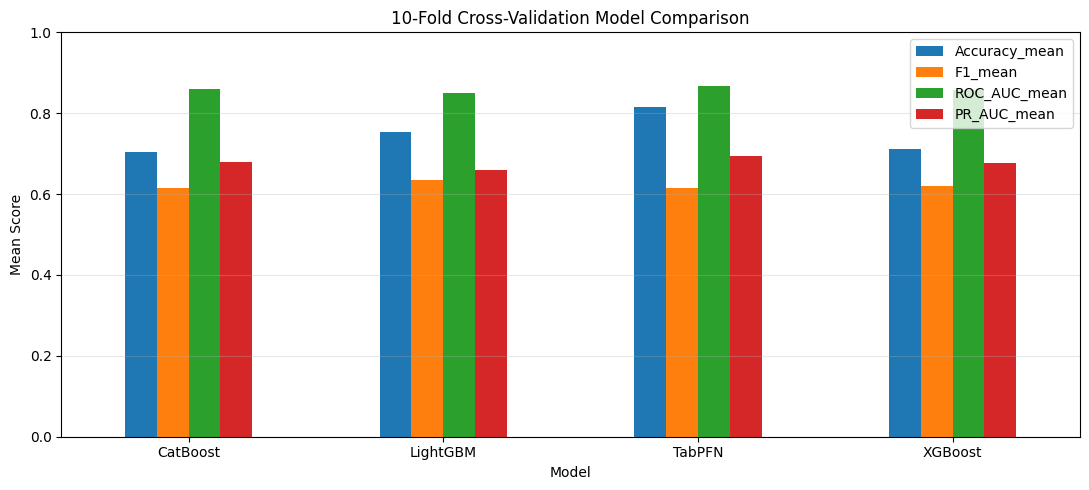

Saved: ten_fold_cv_results.csv
Saved: ten_fold_cv_summary.csv
Saved: cross_validation_model_comparison.png


In [32]:
# Cell 32 — Save and plot 10-fold CV results

cv_results_df.to_csv(f"{OUTPUT_DIR}/ten_fold_cv_results.csv", index=False)
cv_summary_df.to_csv(f"{OUTPUT_DIR}/ten_fold_cv_summary.csv", index=False)

cv_plot_df = cv_summary_df.set_index("Model")[
    ["Accuracy_mean", "F1_mean", "ROC_AUC_mean", "PR_AUC_mean"]
]

cv_plot_df.plot(kind="bar", figsize=(11, 5))
plt.title("10-Fold Cross-Validation Model Comparison")
plt.ylabel("Mean Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(f"{FIGURE_DIR}/cross_validation_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ten_fold_cv_results.csv")
print("Saved: ten_fold_cv_summary.csv")
print("Saved: cross_validation_model_comparison.png")

In [33]:
# Cell 33 — Profit sensitivity analysis under different business assumptions

campaign_cost_values = [50, 100, 200, 500]
retention_rate_values = [0.3, 0.5, 0.6]

sensitivity_results = []

for retention_rate_s in retention_rate_values:
    for campaign_cost_s in campaign_cost_values:
        for model_name, val_probs in val_prob_dict.items():

            best_t, best_val_profit, _ = find_best_profit_threshold(
                y_val,
                val_probs,
                cltv_val,
                retention_rate=retention_rate_s,
                campaign_cost=campaign_cost_s
            )

            test_probs = test_prob_dict[model_name]

            test_profit = calculate_total_profit(
                y_test,
                test_probs,
                cltv_test,
                threshold=best_t,
                retention_rate=retention_rate_s,
                campaign_cost=campaign_cost_s
            )

            profit_top_20 = calculate_profit_at_top_k(
                y_test,
                test_probs,
                cltv_test,
                top_k_percent=0.20,
                retention_rate=retention_rate_s,
                campaign_cost=campaign_cost_s
            )

            cltv_recall = calculate_cltv_weighted_recall(
                y_test,
                test_probs,
                cltv_test,
                threshold=best_t
            )

            class_metrics = evaluate_classification(
                y_test,
                test_probs,
                threshold=best_t
            )

            sensitivity_results.append({
                "Model": model_name,
                "Retention_Rate": retention_rate_s,
                "Campaign_Cost": campaign_cost_s,
                "Best_Threshold": best_t,
                "Validation_Profit": best_val_profit,
                "Test_Profit": test_profit,
                "Profit_Top_20%": profit_top_20,
                "CLTV_Weighted_Recall": cltv_recall,
                "Precision": class_metrics["Precision"],
                "Recall": class_metrics["Recall"],
                "F1": class_metrics["F1"],
                "ROC_AUC": class_metrics["ROC_AUC"],
                "PR_AUC": class_metrics["PR_AUC"]
            })

sensitivity_df = pd.DataFrame(sensitivity_results)

display(
    sensitivity_df.sort_values(
        by=["Retention_Rate", "Campaign_Cost", "Test_Profit"],
        ascending=[True, True, False]
    )
)

,Model,Retention_Rate,Campaign_Cost,Best_Threshold,Validation_Profit,Test_Profit,Profit_Top_20%,CLTV_Weighted_Recall,Precision,Recall,F1,ROC_AUC,PR_AUC
2,CatBoost,0.3,50,0.40,292487.9,285434.4,157120.6,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
0,XGBoost,0.3,50,0.40,281216.4,282690.3,157703.5,0.913584,0.463768,0.914286,0.615385,0.850602,0.652490
1,LightGBM,0.3,50,0.41,246561.4,246333.1,158246.5,0.787253,0.529691,0.796429,0.636234,0.847077,0.638988
3,TabPFN,0.3,50,0.40,195734.9,203837.2,159598.9,0.644467,0.621262,0.667857,0.643718,0.867751,0.690185
6,CatBoost,0.3,100,0.40,263437.9,256334.4,146570.6,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
4,XGBoost,0.3,100,0.40,253466.4,255090.3,147153.5,0.913584,0.463768,0.914286,0.615385,0.850602,0.652490
5,LightGBM,0.3,100,0.41,225511.4,225283.1,147696.5,0.787253,0.529691,0.796429,0.636234,0.847077,0.638988
7,TabPFN,0.3,100,0.40,181384.9,188787.2,149048.9,0.644467,0.621262,0.667857,0.643718,0.867751,0.690185
10,CatBoost,0.3,200,0.40,205337.9,198134.4,125470.6,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
8,XGBoost,0.3,200,0.44,198596.3,197973.2,126053.5,0.896751,0.472795,0.900000,0.619926,0.850602,0.652490


In [34]:
# Cell 34 — Identify best model for each business scenario

best_sensitivity_df = (
    sensitivity_df
    .sort_values(by="Test_Profit", ascending=False)
    .groupby(["Retention_Rate", "Campaign_Cost"])
    .head(1)
    .reset_index(drop=True)
)

display(best_sensitivity_df)

,Model,Retention_Rate,Campaign_Cost,Best_Threshold,Validation_Profit,Test_Profit,Profit_Top_20%,CLTV_Weighted_Recall,Precision,Recall,F1,ROC_AUC,PR_AUC
0,CatBoost,0.6,50,0.40,614025.8,599968.8,324791.2,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
1,CatBoost,0.6,100,0.40,584975.8,570868.8,314241.2,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
2,CatBoost,0.6,200,0.40,526875.8,512668.8,293141.2,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
3,CatBoost,0.5,50,0.40,506846.5,495124.0,268901.0,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
4,CatBoost,0.5,100,0.40,477796.5,466024.0,258351.0,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
5,CatBoost,0.5,200,0.40,419696.5,407824.0,237251.0,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
6,CatBoost,0.6,500,0.57,358307.6,350729.0,229841.2,0.877735,0.498982,0.875000,0.635538,0.859487,0.654828
7,CatBoost,0.3,50,0.40,292487.9,285434.4,157120.6,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
8,CatBoost,0.3,100,0.40,263437.9,256334.4,146570.6,0.926080,0.445017,0.925000,0.600928,0.859487,0.654828
9,CatBoost,0.5,500,0.57,259423.0,251357.5,173951.0,0.877735,0.498982,0.875000,0.635538,0.859487,0.654828


In [35]:
# Cell 35 — Evaluate fairness across Gender and Senior Citizen

fairness_results = []

for model_name, probs in test_prob_dict.items():
    threshold = best_thresholds[model_name]

    gender_dp, gender_eo, gender_fpr = evaluate_fairness(
        y_test,
        probs,
        gender_test,
        threshold
    )

    senior_dp, senior_eo, senior_fpr = evaluate_fairness(
        y_test,
        probs,
        senior_test,
        threshold
    )

    fairness_results.append({
        "Model": model_name,
        "Threshold": threshold,
        "Gender_DP_Gap": gender_dp,
        "Gender_EO_Gap": gender_eo,
        "Gender_FPR_Gap": gender_fpr,
        "Senior_DP_Gap": senior_dp,
        "Senior_EO_Gap": senior_eo,
        "Senior_FPR_Gap": senior_fpr
    })

fairness_df = pd.DataFrame(fairness_results)

display(fairness_df.sort_values(by="Gender_DP_Gap"))

,Model,Threshold,Gender_DP_Gap,Gender_EO_Gap,Gender_FPR_Gap,Senior_DP_Gap,Senior_EO_Gap,Senior_FPR_Gap
0,XGBoost,0.40,0.000988,0.024909,0.000245,0.322179,0.080650,0.304866
3,TabPFN,0.40,0.001353,0.021489,0.001888,0.301975,0.162276,0.220367
2,CatBoost,0.40,0.010311,0.010362,0.002776,0.330655,0.084228,0.325847
1,LightGBM,0.41,0.013999,0.044459,0.043054,0.321792,0.168780,0.242609


In [36]:
# Cell 36 — Combine classification, profit, and fairness results

final_results_df = (
    optimized_classification_df
    .merge(optimized_profit_df, on=["Model", "Best_Threshold"], how="left")
    .merge(
        fairness_df.rename(columns={"Threshold": "Best_Threshold"}),
        on=["Model", "Best_Threshold"],
        how="left"
    )
)

final_results_df = final_results_df.sort_values(
    by=["Total_Profit", "F1"],
    ascending=False
)

display(final_results_df)

,Model,Best_Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score,Total_Profit,Profit_Top_20%,CLTV_Weighted_Recall,Gender_DP_Gap,Gender_EO_Gap,Gender_FPR_Gap,Senior_DP_Gap,Senior_EO_Gap,Senior_FPR_Gap
2,CatBoost,0.40,0.674551,0.445017,0.925000,0.600928,0.859487,0.654828,0.191732,599968.8,324791.2,0.926080,0.010311,0.010362,0.002776,0.330655,0.084228,0.325847
0,XGBoost,0.40,0.697256,0.463768,0.914286,0.615385,0.850602,0.652490,0.186530,592980.6,325957.0,0.913584,0.000988,0.024909,0.000245,0.322179,0.080650,0.304866
1,LightGBM,0.41,0.758751,0.529691,0.796429,0.636234,0.847077,0.638988,0.163924,513716.2,327043.0,0.787253,0.013999,0.044459,0.043054,0.321792,0.168780,0.242609
3,TabPFN,0.40,0.804163,0.621262,0.667857,0.643718,0.867751,0.690185,0.127980,422724.4,329747.8,0.644467,0.001353,0.021489,0.001888,0.301975,0.162276,0.220367


In [37]:
# Cell 37 — SMOTE comparison for XGBoost and LightGBM

# SMOTE is used only as a comparison.
# It is not used for CatBoost or TabPFN.

smote = SMOTE(random_state=RANDOM_STATE)

X_train_tree_smote, y_train_smote = smote.fit_resample(X_train_tree, y_train)

print("Original training shape:", X_train_tree.shape)
print("SMOTE training shape:", X_train_tree_smote.shape)

# XGBoost with SMOTE
xgb_smote_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_smote_model.fit(X_train_tree_smote, y_train_smote)

xgb_smote_test_probs = xgb_smote_model.predict_proba(X_test_tree)[:, 1]

# LightGBM with SMOTE
lgbm_smote_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lgbm_smote_model.fit(X_train_tree_smote, y_train_smote)

lgbm_smote_test_probs = lgbm_smote_model.predict_proba(X_test_tree)[:, 1]

smote_prob_dict = {
    "XGBoost_SMOTE": xgb_smote_test_probs,
    "LightGBM_SMOTE": lgbm_smote_test_probs
}

print("SMOTE models trained.")

Original training shape: (4929, 1178)
SMOTE training shape: (7242, 1178)
SMOTE models trained.


In [38]:
# Cell 38 — Evaluate SMOTE comparison

smote_results = []

for model_name, probs in smote_prob_dict.items():
    metrics = evaluate_classification(y_test, probs, threshold=0.5)

    profit = calculate_total_profit(
        y_test,
        probs,
        cltv_test,
        threshold=0.5,
        retention_rate=retention_rate,
        campaign_cost=campaign_cost
    )

    cltv_recall = calculate_cltv_weighted_recall(
        y_test,
        probs,
        cltv_test,
        threshold=0.5
    )

    gender_dp, gender_eo, gender_fpr = evaluate_fairness(
        y_test,
        probs,
        gender_test,
        threshold=0.5
    )

    smote_results.append({
        "Model": model_name,
        "Threshold": 0.5,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
        "ROC_AUC": metrics["ROC_AUC"],
        "PR_AUC": metrics["PR_AUC"],
        "Brier_Score": metrics["Brier_Score"],
        "Total_Profit": profit,
        "CLTV_Weighted_Recall": cltv_recall,
        "Gender_DP_Gap": gender_dp,
        "Gender_EO_Gap": gender_eo,
        "Gender_FPR_Gap": gender_fpr
    })

smote_results_df = pd.DataFrame(smote_results)

display(smote_results_df.sort_values(by="F1", ascending=False))

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score,Total_Profit,CLTV_Weighted_Recall,Gender_DP_Gap,Gender_EO_Gap,Gender_FPR_Gap
0,XGBoost_SMOTE,0.5,0.799432,0.637097,0.564286,0.598485,0.860471,0.668972,0.131224,352160.0,0.536685,0.014693,0.032974,0.001491
1,LightGBM_SMOTE,0.5,0.793756,0.623016,0.560714,0.590226,0.844503,0.632532,0.143914,353970.6,0.539645,0.010902,0.068858,0.016445


In [39]:
# Cell 39 — Create SMOTE benefit comparison table

# SMOTE models were evaluated at threshold 0.5.
# Therefore, the fair comparison is Original XGBoost/LightGBM at threshold 0.5 vs SMOTE XGBoost/LightGBM at threshold 0.5.

original_for_smote_compare = default_results_df[
    default_results_df["Model"].isin(["XGBoost", "LightGBM"])
].copy()

original_profit_for_smote_compare = default_profit_df[
    default_profit_df["Model"].isin(["XGBoost", "LightGBM"])
].copy()

original_smote_compare_df = original_for_smote_compare.merge(
    original_profit_for_smote_compare,
    on="Model",
    how="left"
)

original_smote_compare_df["Version"] = "Original"

smote_compare_df = smote_results_df.copy()
smote_compare_df["Model"] = smote_compare_df["Model"].str.replace("_SMOTE", "", regex=False)
smote_compare_df["Version"] = "SMOTE"

common_cols = [
    "Model",
    "Version",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "Total_Profit",
    "CLTV_Weighted_Recall"
]

smote_benefit_df = pd.concat(
    [
        original_smote_compare_df[common_cols],
        smote_compare_df[common_cols]
    ],
    ignore_index=True
)

display(
    smote_benefit_df.sort_values(
        by=["Model", "Version"]
    )
)

,Model,Version,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Total_Profit,CLTV_Weighted_Recall
1,LightGBM,Original,0.771050,0.549479,0.753571,0.635542,0.847077,0.638988,488114.4,0.746840
3,LightGBM,SMOTE,0.793756,0.623016,0.560714,0.590226,0.844503,0.632532,353970.6,0.539645
0,XGBoost,Original,0.725639,0.489960,0.871429,0.627249,0.850602,0.652490,564883.8,0.868246
2,XGBoost,SMOTE,0.799432,0.637097,0.564286,0.598485,0.860471,0.668972,352160.0,0.536685


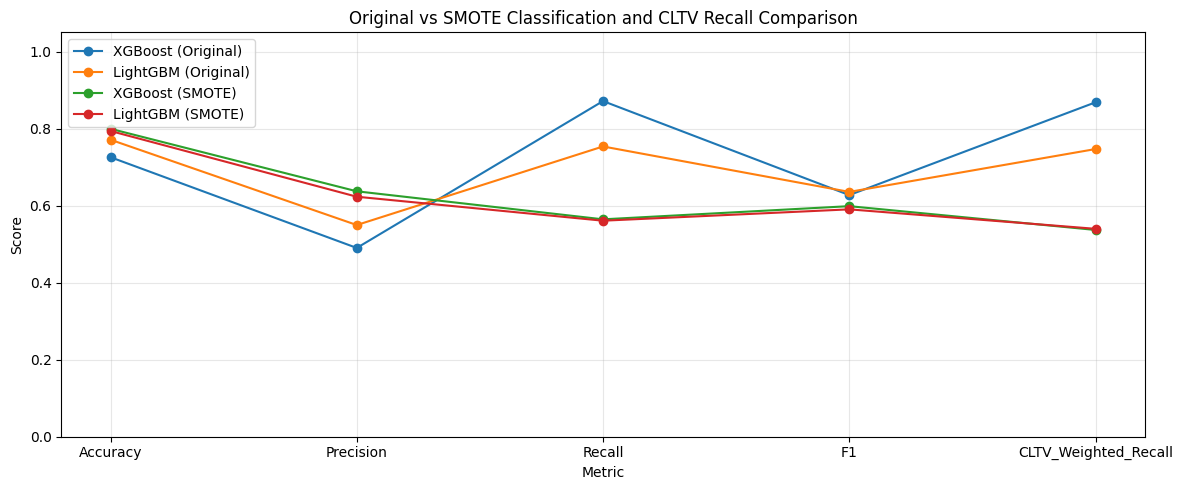

Saved: smote_benefit_classification_comparison.png


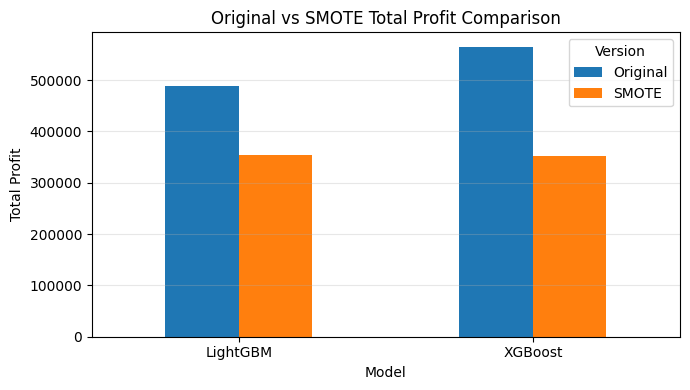

Saved: smote_benefit_profit_comparison.png


In [40]:
# Cell 40 — Plot SMOTE benefit and limitation

# Plot 1: classification metrics and CLTV recall
plot_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "CLTV_Weighted_Recall"
]

smote_melted_df = smote_benefit_df.melt(
    id_vars=["Model", "Version"],
    value_vars=plot_metrics,
    var_name="Metric",
    value_name="Score"
)

smote_melted_df["Model_Version"] = (
    smote_melted_df["Model"] + " (" + smote_melted_df["Version"] + ")"
)

plt.figure(figsize=(12, 5))

for label in smote_melted_df["Model_Version"].unique():
    temp_df = smote_melted_df[smote_melted_df["Model_Version"] == label]
    plt.plot(
        temp_df["Metric"],
        temp_df["Score"],
        marker="o",
        label=label
    )

plt.title("Original vs SMOTE Classification and CLTV Recall Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/smote_benefit_classification_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved: smote_benefit_classification_comparison.png")


# Plot 2: profit comparison separately because profit has a different scale
profit_plot_df = smote_benefit_df.pivot(
    index="Model",
    columns="Version",
    values="Total_Profit"
)

plt.figure(figsize=(7, 4))
profit_plot_df.plot(kind="bar", ax=plt.gca())

plt.title("Original vs SMOTE Total Profit Comparison")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/smote_benefit_profit_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved: smote_benefit_profit_comparison.png")

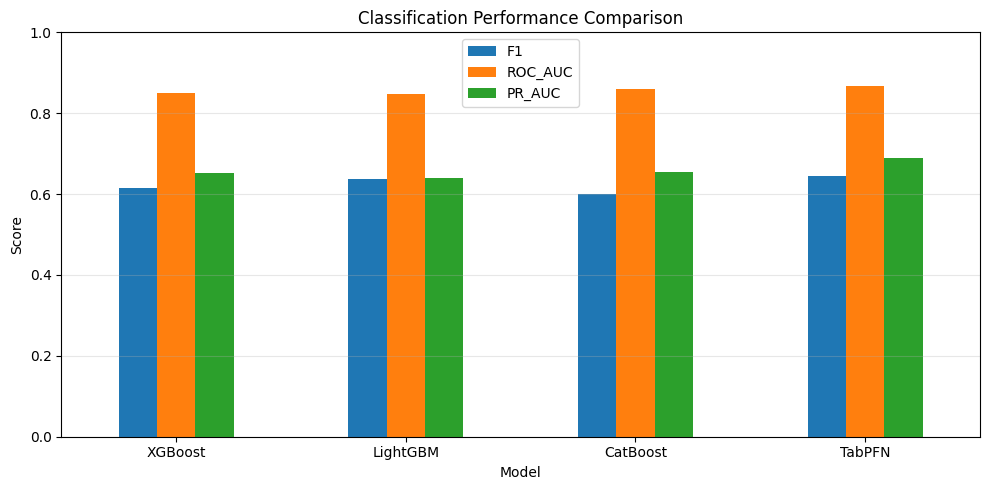

Saved: classification_performance_comparison.png


In [41]:
# Cell 41 — Plot and save classification performance comparison

plot_df = optimized_classification_df.set_index("Model")[["F1", "ROC_AUC", "PR_AUC"]]

plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Classification Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(f"{FIGURE_DIR}/classification_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: classification_performance_comparison.png")

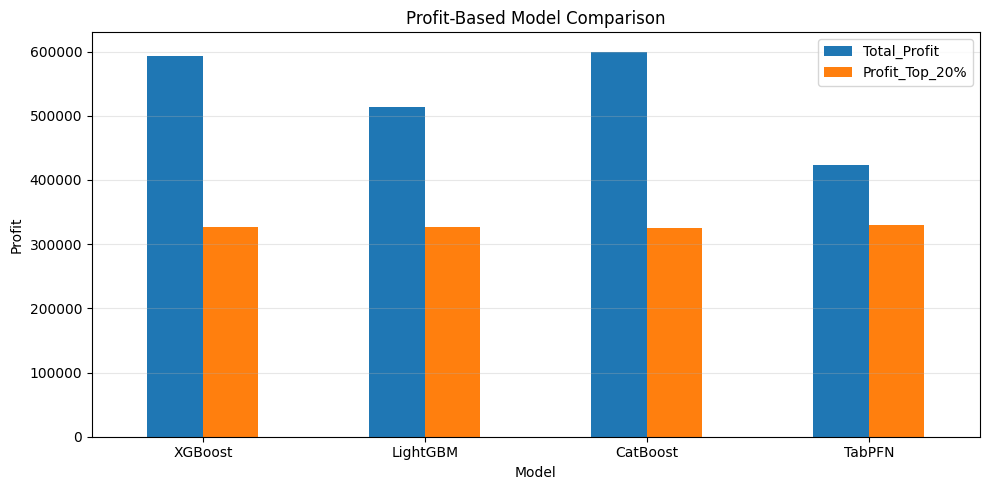

Saved: profit_based_model_comparison.png


In [42]:
# Cell 42 — Plot and save profit comparison

profit_plot_df = optimized_profit_df.set_index("Model")[["Total_Profit", "Profit_Top_20%"]]

profit_plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Profit-Based Model Comparison")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(f"{FIGURE_DIR}/profit_based_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: profit_based_model_comparison.png")

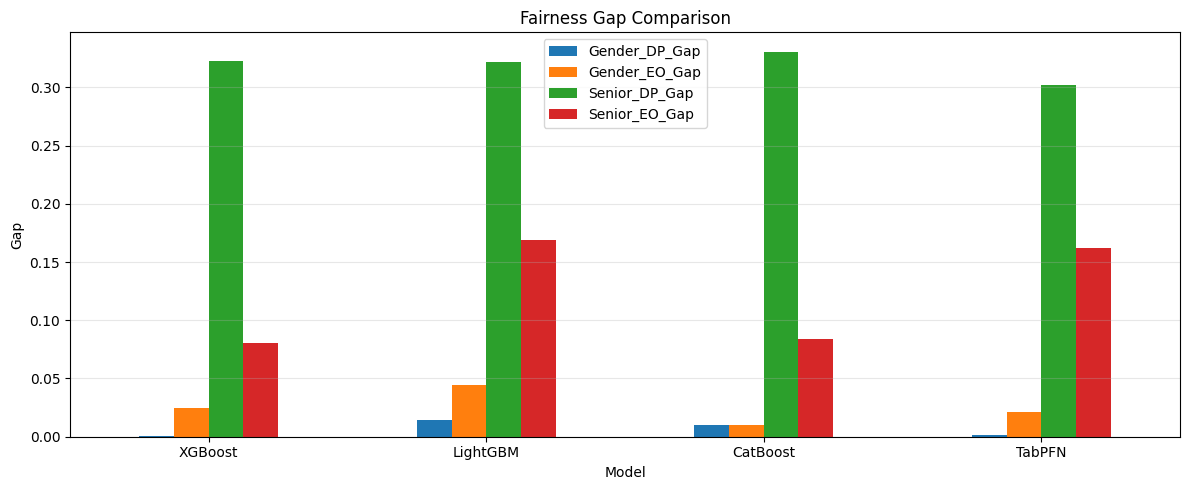

Saved: fairness_gap_comparison.png


In [43]:
# Cell 43 — Plot and save fairness comparison

fairness_plot_df = fairness_df.set_index("Model")[
    ["Gender_DP_Gap", "Gender_EO_Gap", "Senior_DP_Gap", "Senior_EO_Gap"]
]

fairness_plot_df.plot(kind="bar", figsize=(12, 5))
plt.title("Fairness Gap Comparison")
plt.ylabel("Gap")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(f"{FIGURE_DIR}/fairness_gap_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fairness_gap_comparison.png")

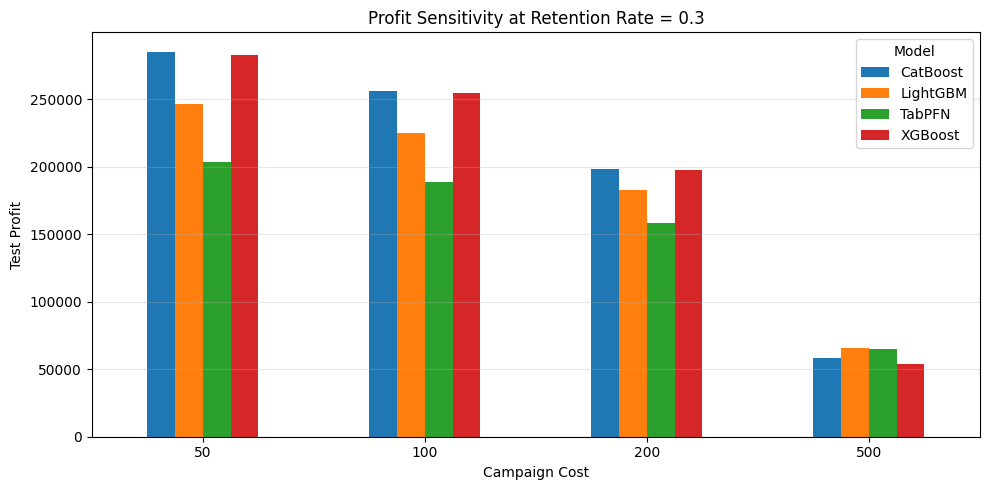

Saved: profit_sensitivity_retention_rate_0.3.png


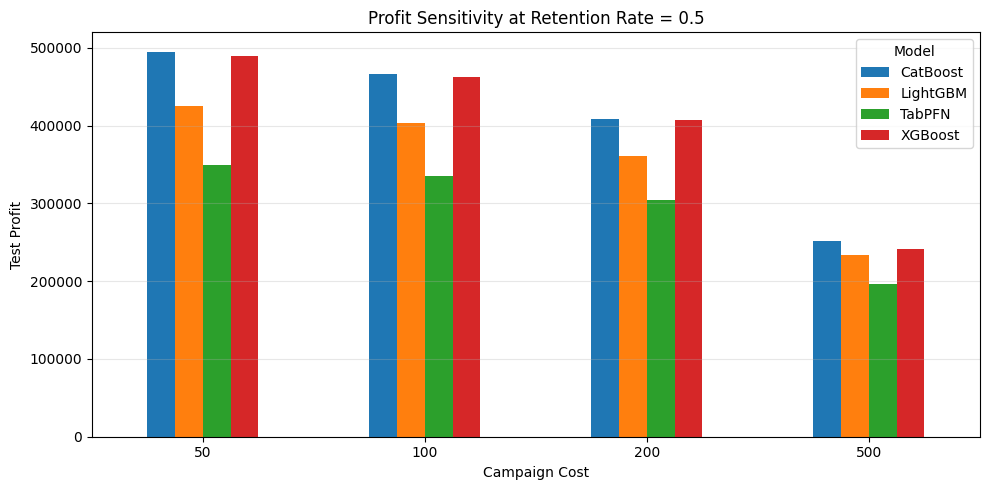

Saved: profit_sensitivity_retention_rate_0.5.png


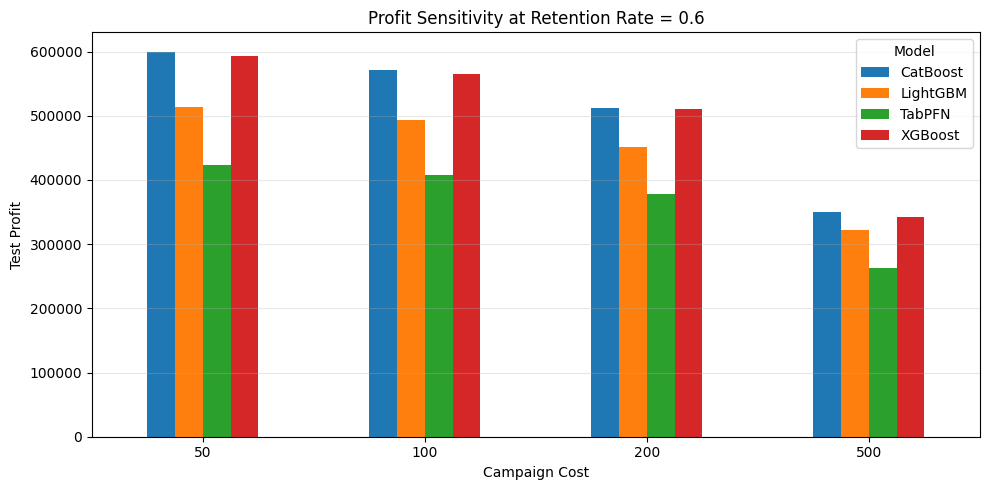

Saved: profit_sensitivity_retention_rate_0.6.png


In [44]:
# Cell 44 — Plot and save profit sensitivity results

for retention_rate_s in retention_rate_values:
    temp_df = sensitivity_df[sensitivity_df["Retention_Rate"] == retention_rate_s]

    pivot_df = temp_df.pivot(
        index="Campaign_Cost",
        columns="Model",
        values="Test_Profit"
    )

    pivot_df.plot(kind="bar", figsize=(10, 5))
    plt.title(f"Profit Sensitivity at Retention Rate = {retention_rate_s}")
    plt.xlabel("Campaign Cost")
    plt.ylabel("Test Profit")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    filename = f"profit_sensitivity_retention_rate_{retention_rate_s}.png"
    plt.savefig(f"{FIGURE_DIR}/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", filename)

In [45]:
# Cell 45 — Create retention priority list using the best model

best_model_name = final_results_df.iloc[0]["Model"]
best_probs = test_prob_dict[best_model_name]

expected_profit, profitable_target_mask = calculate_expected_profit_targeting(
    best_probs,
    cltv_test,
    retention_rate=retention_rate,
    campaign_cost=campaign_cost
)

priority_df = X_test.copy()

priority_df["Actual_Churn"] = y_test.values
priority_df["Predicted_Churn_Probability"] = best_probs
priority_df["CLTV"] = cltv_test.values
priority_df["Expected_Profit"] = expected_profit
priority_df["Target_For_Retention"] = profitable_target_mask
priority_df["Churn_Reason"] = reason_test.values

def assign_priority(prob, expected_profit_value):
    """
    Assign retention priority level.
    """
    if expected_profit_value > 0 and prob >= 0.70:
        return "High"
    elif expected_profit_value > 0 and prob >= 0.40:
        return "Medium"
    else:
        return "Low"

priority_df["Retention_Priority"] = priority_df.apply(
    lambda row: assign_priority(
        row["Predicted_Churn_Probability"],
        row["Expected_Profit"]
    ),
    axis=1
)

priority_df = priority_df.sort_values(by="Expected_Profit", ascending=False)

print("Best model:", best_model_name)
print("Priority distribution:")
display(priority_df["Retention_Priority"].value_counts())

display(priority_df.head(20))

Best model: CatBoost
Priority distribution:


,count
Retention_Priority,
Low,475
High,385
Medium,197


,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,ServiceCount,ContractRisk,SupportRisk,AutoPayment,Actual_Churn,Predicted_Churn_Probability,Expected_Profit,Target_For_Retention,Churn_Reason,Retention_Priority
1818,La Puente,Male,No,No,No,1,Yes,Yes,Fiber optic,No,...,4,1,1,0,1,0.977132,3445.396061,True,Attitude of support person,High
1481,Fellows,Female,No,No,No,3,Yes,Yes,Fiber optic,No,...,2,1,1,0,1,0.955914,3361.465381,True,Attitude of service provider,High
886,Gardena,Male,Yes,Yes,No,1,Yes,Yes,Fiber optic,No,...,4,1,1,0,1,0.977794,3349.790681,True,Price too high,High
145,Anaheim,Female,Yes,No,No,4,Yes,Yes,Fiber optic,No,...,4,1,1,0,1,0.965367,3314.111986,True,Competitor had better devices,High
6213,Brentwood,Male,No,No,No,1,Yes,No,Fiber optic,No,...,3,1,1,0,0,0.971744,3304.850523,True,NaN,High
1868,Apple Valley,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,2,1,1,0,1,0.948286,3272.224336,True,Competitor offered more data,High
5638,Long Beach,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,2,1,1,0,0,0.945776,3228.247860,True,NaN,High
598,Piru,Male,No,Yes,No,1,Yes,Yes,Fiber optic,No,...,2,1,1,0,1,0.983217,3226.473290,True,Attitude of service provider,High
1422,Newberry Springs,Male,No,No,No,13,Yes,No,Fiber optic,No,...,2,1,1,0,1,0.906115,3192.443074,True,Lack of self-service on Website,High
502,Pomona,Male,No,Yes,No,49,Yes,Yes,Fiber optic,No,...,5,1,1,0,1,0.886914,3189.720975,True,Attitude of support person,High


In [46]:
# Cell 46 — Analyze churn reasons for business interpretation

actual_churn_test = priority_df[priority_df["Actual_Churn"] == 1]

print("Top churn reasons among actual churned customers:")
top_churn_reasons = actual_churn_test["Churn_Reason"].value_counts().head(15)
display(top_churn_reasons)

high_priority_churners = priority_df[
    (priority_df["Actual_Churn"] == 1) &
    (priority_df["Retention_Priority"] == "High")
]

print("\nTop churn reasons among high-priority churned customers:")
top_high_priority_reasons = high_priority_churners["Churn_Reason"].value_counts().head(15)
display(top_high_priority_reasons)

Top churn reasons among actual churned customers:


,count
Churn_Reason,
Attitude of support person,35
Competitor offered higher download speeds,29
Don't know,28
Competitor had better devices,25
Competitor offered more data,22
Price too high,20
Attitude of service provider,20
Competitor made better offer,16
Service dissatisfaction,13



Top churn reasons among high-priority churned customers:


,count
Churn_Reason,
Attitude of support person,29
Competitor offered higher download speeds,22
Competitor had better devices,21
Don't know,21
Attitude of service provider,18
Competitor offered more data,18
Price too high,15
Competitor made better offer,12
Lack of self-service on Website,10


In [47]:
# Cell 47 — Map churn reasons to possible retention actions

retention_actions = {
    "Competitor made better offer": "Offer personalized discount or bundle package",
    "Competitor had better devices": "Provide device upgrade or loyalty offer",
    "Competitor offered more data": "Offer higher data plan or bonus data",
    "Competitor offered higher download speeds": "Provide speed upgrade or premium plan",
    "Price too high": "Offer lower-cost plan or temporary discount",
    "Product dissatisfaction": "Improve service quality and provide support follow-up",
    "Network reliability": "Escalate technical support and network issue resolution",
    "Service dissatisfaction": "Assign customer care follow-up",
    "Lack of affordable download/upload speed": "Offer affordable speed-based package",
    "Attitude of support person": "Escalate support quality issue",
    "Attitude of service provider": "Escalate service experience issue",
    "Poor expertise of online support": "Provide expert technical support",
    "Poor expertise of phone support": "Provide senior support callback",
    "Lack of self-service on Website": "Improve self-service support and provide guided assistance",
    "Limited range of services": "Offer customized service bundle",
    "Long distance charges": "Offer long-distance charge discount or suitable plan",
    "Extra data charges": "Offer data add-on discount or higher data package",
    "Don't know": "Send general retention survey and targeted offer"
}

priority_df["Recommended_Action"] = priority_df["Churn_Reason"].map(retention_actions)
priority_df["Recommended_Action"] = priority_df["Recommended_Action"].fillna("Provide personalized retention follow-up")

display(priority_df[[
    "Predicted_Churn_Probability",
    "CLTV",
    "Expected_Profit",
    "Retention_Priority",
    "Churn_Reason",
    "Recommended_Action"
]].head(20))

,Predicted_Churn_Probability,CLTV,Expected_Profit,Retention_Priority,Churn_Reason,Recommended_Action
1818,0.977132,5962,3445.396061,High,Attitude of support person,Escalate support quality issue
1481,0.955914,5948,3361.465381,High,Attitude of service provider,Escalate service experience issue
886,0.977794,5795,3349.790681,High,Price too high,Offer lower-cost plan or temporary discount
145,0.965367,5808,3314.111986,High,Competitor had better devices,Provide device upgrade or loyalty offer
6213,0.971744,5754,3304.850523,High,NaN,Provide personalized retention follow-up
1868,0.948286,5839,3272.224336,High,Competitor offered more data,Offer higher data plan or bonus data
5638,0.945776,5777,3228.247860,High,NaN,Provide personalized retention follow-up
598,0.983217,5554,3226.473290,High,Attitude of service provider,Escalate service experience issue
1422,0.906115,5964,3192.443074,High,Lack of self-service on Website,Improve self-service support and provide guide...
502,0.886914,6088,3189.720975,High,Attitude of support person,Escalate support quality issue


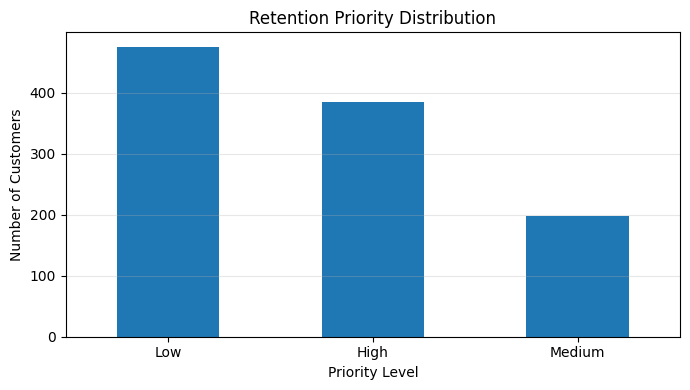

Saved: retention_priority_distribution.png


In [48]:
# Cell 48 — Plot and save retention priority distribution

priority_df["Retention_Priority"].value_counts().plot(kind="bar", figsize=(7, 4))
plt.title("Retention Priority Distribution")
plt.xlabel("Priority Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(f"{FIGURE_DIR}/retention_priority_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: retention_priority_distribution.png")

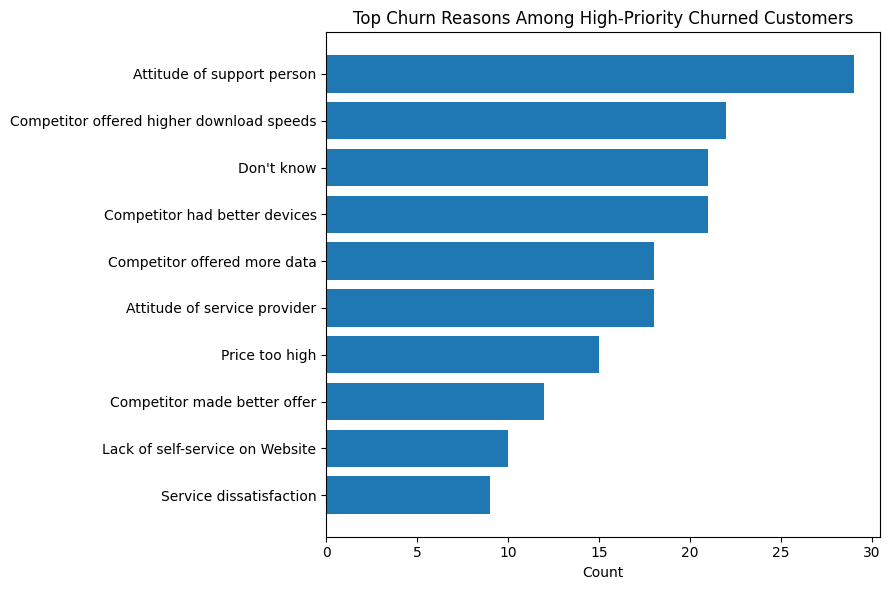

Saved: top_churn_reasons_high_priority.png


In [49]:
# Cell 49 — Plot and save top churn reasons among high-priority churners

top_reasons = high_priority_churners["Churn_Reason"].value_counts().head(10).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_reasons.index, top_reasons.values)
plt.title("Top Churn Reasons Among High-Priority Churned Customers")
plt.xlabel("Count")
plt.tight_layout()

plt.savefig(f"{FIGURE_DIR}/top_churn_reasons_high_priority.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: top_churn_reasons_high_priority.png")

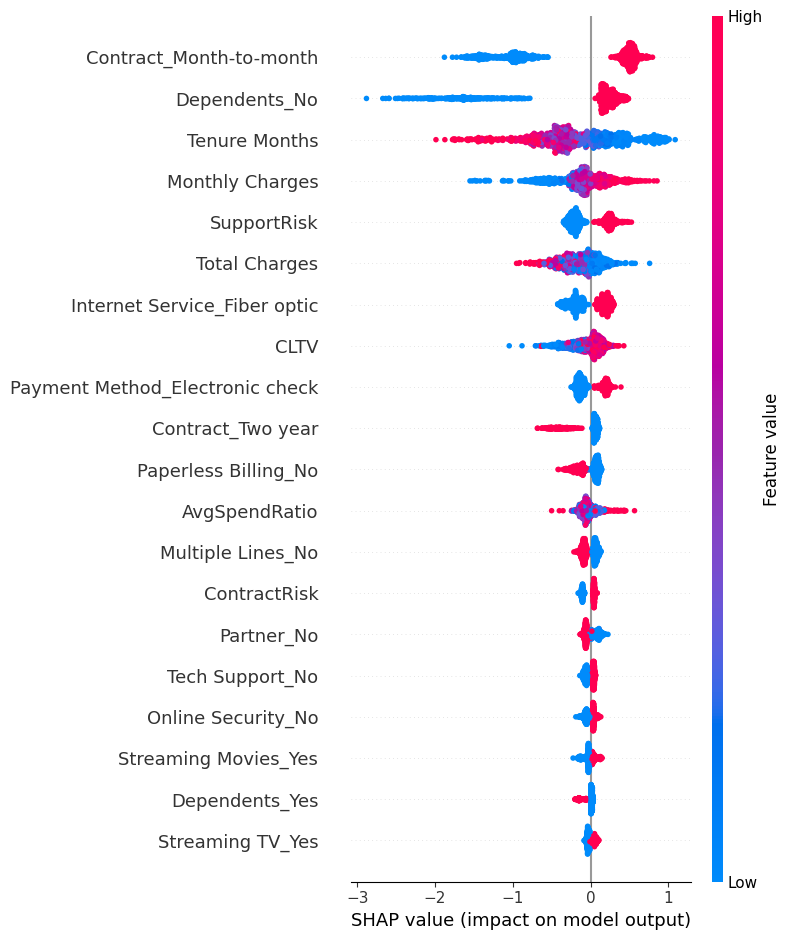

Saved: xgboost_shap_summary.png


In [50]:
# Cell 50 — SHAP explainability for XGBoost

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_test_tree)

shap.summary_plot(xgb_shap_values, X_test_tree, show=False)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/xgboost_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: xgboost_shap_summary.png")

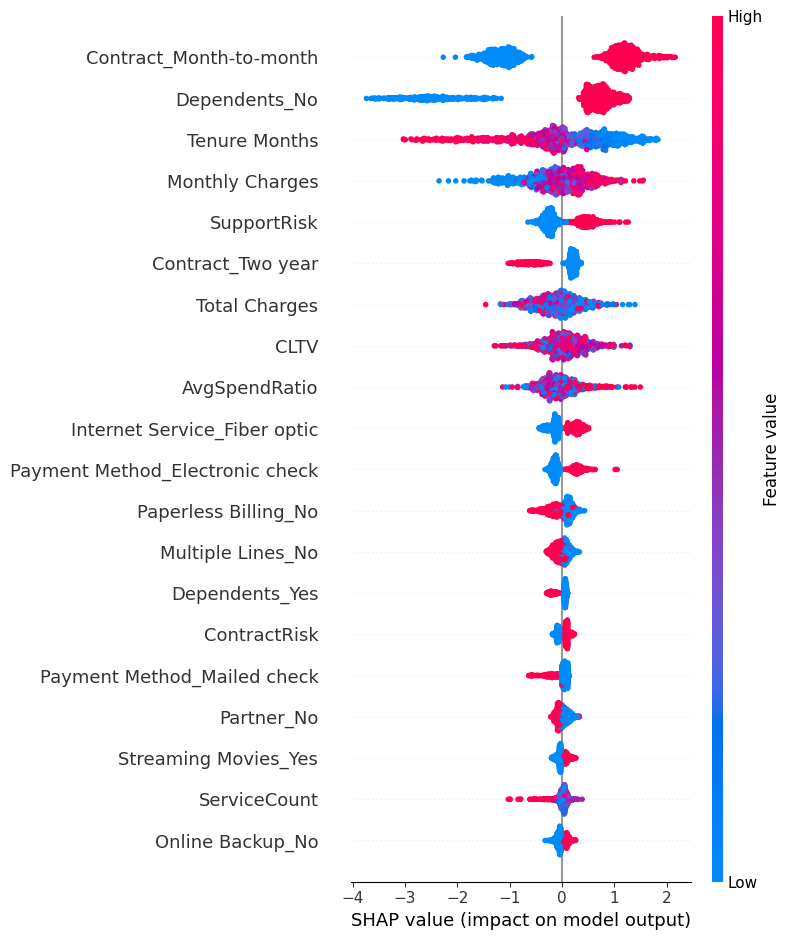

Saved: lightgbm_shap_summary.png


In [51]:
# Cell 51 — SHAP explainability for LightGBM

lgbm_explainer = shap.TreeExplainer(lgbm_model)
lgbm_shap_values = lgbm_explainer.shap_values(X_test_tree)

if isinstance(lgbm_shap_values, list):
    lgbm_shap_values_to_plot = lgbm_shap_values[1]
else:
    lgbm_shap_values_to_plot = lgbm_shap_values

shap.summary_plot(lgbm_shap_values_to_plot, X_test_tree, show=False)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/lightgbm_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: lightgbm_shap_summary.png")

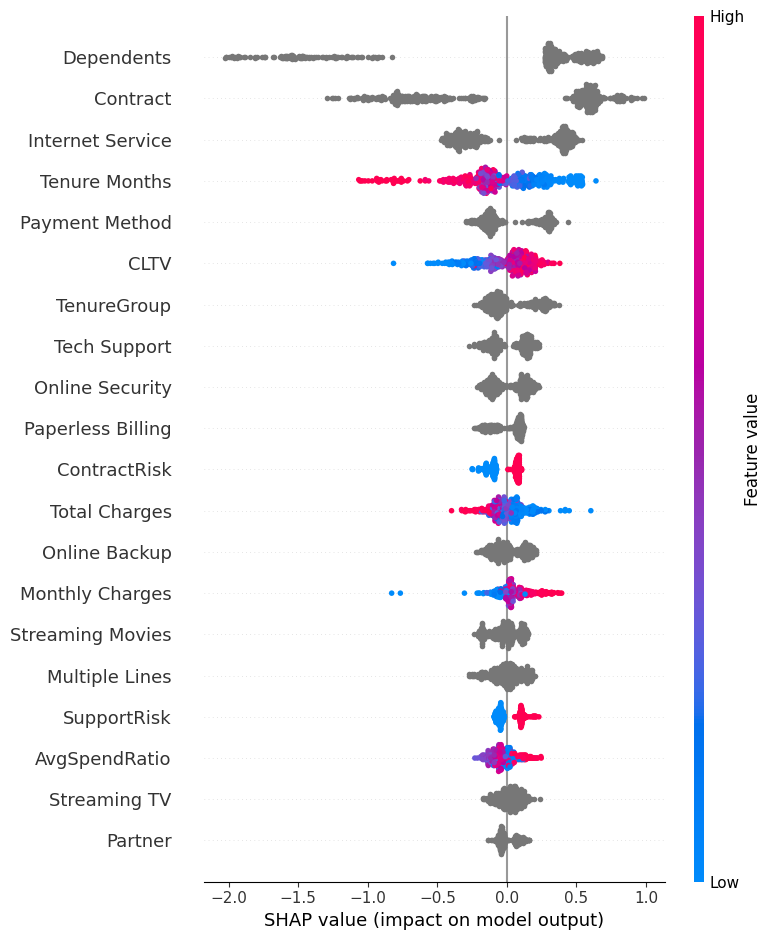

Saved: catboost_shap_summary.png


In [52]:
# Cell 52 — SHAP explainability for CatBoost

shap_sample_size = min(500, len(X_test_cat))
X_test_cat_sample = X_test_cat.sample(shap_sample_size, random_state=RANDOM_STATE)

cat_explainer = shap.TreeExplainer(cat_model)
cat_shap_values = cat_explainer.shap_values(X_test_cat_sample)

shap.summary_plot(cat_shap_values, X_test_cat_sample, show=False)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/catboost_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: catboost_shap_summary.png")

In [53]:
# Cell 53 — Permutation importance for TabPFN


tabpfn_perm_result = permutation_importance(
    tabpfn_model,
    X_test_tabpfn,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="f1"
)

tabpfn_importance_df = pd.DataFrame({
    "Feature": tabpfn_feature_names,
    "Importance": tabpfn_perm_result.importances_mean
}).sort_values(by="Importance", ascending=False)

print("TabPFN permutation importance:")
display(tabpfn_importance_df.head(20))

TabPFN permutation importance:


,Feature,Importance
14,Contract,0.146094
18,Tenure Months,0.099599
24,ContractRisk,0.058499
7,Internet Service,0.051587
4,Dependents,0.045663
25,SupportRisk,0.035496
15,Paperless Billing,0.020903
8,Online Security,0.019517
11,Tech Support,0.019126
6,Multiple Lines,0.016977


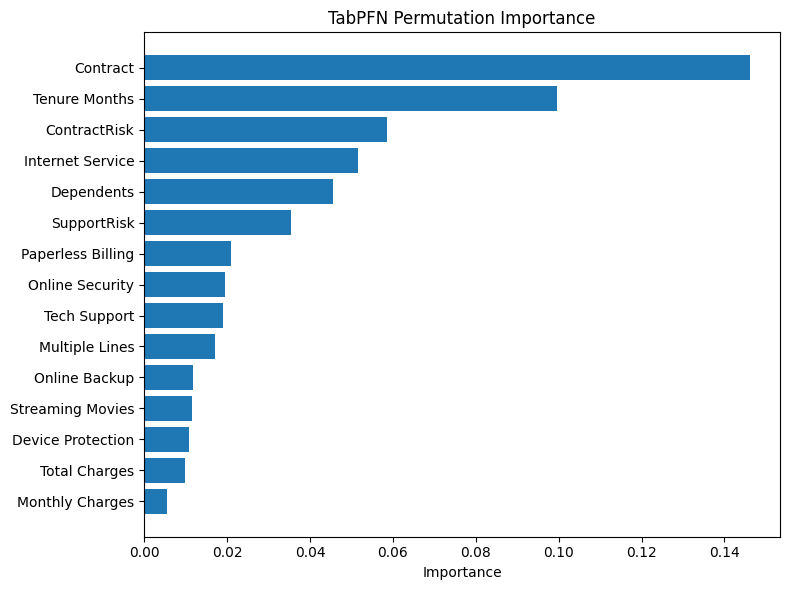

Saved: tabpfn_permutation_importance.png


In [54]:
# Cell 54 — Plot and save TabPFN permutation importance

top_n = 15

tabpfn_plot_df = tabpfn_importance_df.head(top_n).sort_values(by="Importance")

plt.figure(figsize=(8, 6))
plt.barh(tabpfn_plot_df["Feature"], tabpfn_plot_df["Importance"])
plt.title("TabPFN Permutation Importance")
plt.xlabel("Importance")
plt.tight_layout()

plt.savefig(f"{FIGURE_DIR}/tabpfn_permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: tabpfn_permutation_importance.png")

In [55]:
# Cell 55 — Save result tables

default_results_df.to_csv(f"{OUTPUT_DIR}/default_classification_results.csv", index=False)
default_profit_df.to_csv(f"{OUTPUT_DIR}/default_profit_results.csv", index=False)
optimized_classification_df.to_csv(f"{OUTPUT_DIR}/optimized_classification_results.csv", index=False)
optimized_profit_df.to_csv(f"{OUTPUT_DIR}/optimized_profit_results.csv", index=False)
sensitivity_df.to_csv(f"{OUTPUT_DIR}/profit_sensitivity_results.csv", index=False)
best_sensitivity_df.to_csv(f"{OUTPUT_DIR}/best_model_by_business_scenario.csv", index=False)
fairness_df.to_csv(f"{OUTPUT_DIR}/fairness_results.csv", index=False)
final_results_df.to_csv(f"{OUTPUT_DIR}/final_combined_results.csv", index=False)
smote_results_df.to_csv(f"{OUTPUT_DIR}/smote_comparison_results.csv", index=False)
priority_df.to_csv(f"{OUTPUT_DIR}/retention_priority_list.csv", index=False)
tabpfn_importance_df.to_csv(f"{OUTPUT_DIR}/tabpfn_permutation_importance.csv", index=False)
try:
    smote_benefit_df.to_csv(f"{OUTPUT_DIR}/smote_benefit_comparison.csv", index=False)
except NameError:
    pass

print("All result tables saved in:", OUTPUT_DIR)

All result tables saved in: telco_churn_results


In [56]:
# Cell 56 — Check saved figure files

print("Saved figures:")
for file_name in sorted(os.listdir(FIGURE_DIR)):
    print(file_name)

Saved figures:
catboost_shap_summary.png
classification_performance_comparison.png
cross_validation_model_comparison.png
fairness_gap_comparison.png
lightgbm_shap_summary.png
profit_based_model_comparison.png
profit_sensitivity_retention_rate_0.3.png
profit_sensitivity_retention_rate_0.5.png
profit_sensitivity_retention_rate_0.6.png
retention_priority_distribution.png
smote_benefit_classification_comparison.png
smote_benefit_profit_comparison.png
tabpfn_permutation_importance.png
top_churn_reasons_high_priority.png
xgboost_shap_summary.png


In [57]:
# Cell 57 — Accuracy-focused threshold optimization using existing trained models

accuracy_threshold_results = []

thresholds = np.arange(0.4, 0.9, 0.01)

for model_name, probs in test_prob_dict.items():
    best_acc = -1
    best_row = None

    for threshold in thresholds:
        y_pred = (probs >= threshold).astype(int)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        profit = calculate_total_profit(
            y_test,
            probs,
            cltv_test,
            threshold=threshold,
            retention_rate=retention_rate,
            campaign_cost=campaign_cost
        )

        cltv_rec = calculate_cltv_weighted_recall(
            y_test,
            probs,
            cltv_test,
            threshold=threshold
        )

        if acc > best_acc:
            best_acc = acc
            best_row = {
                "Model": model_name,
                "Accuracy_Optimized_Threshold": threshold,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1,
                "Total_Profit": profit,
                "CLTV_Weighted_Recall": cltv_rec
            }

    accuracy_threshold_results.append(best_row)

accuracy_threshold_df = pd.DataFrame(accuracy_threshold_results)

display(
    accuracy_threshold_df.sort_values(
        by="Accuracy",
        ascending=False
    )
)

,Model,Accuracy_Optimized_Threshold,Accuracy,Precision,Recall,F1,Total_Profit,CLTV_Weighted_Recall
3,TabPFN,0.53,0.815516,0.699531,0.532143,0.604462,333159.6,0.506137
1,LightGBM,0.76,0.805109,0.644531,0.589286,0.615672,383959.0,0.584086
2,CatBoost,0.83,0.802271,0.651064,0.546429,0.594175,365425.6,0.555257
0,XGBoost,0.83,0.792810,0.635556,0.510714,0.566337,337906.2,0.514008


In [58]:
# Cell 58 — Full threshold trade-off analysis

threshold_tradeoff_results = []

thresholds = np.arange(0.4, 0.9, 0.01)

for model_name, probs in test_prob_dict.items():
    for threshold in thresholds:
        y_pred = (probs >= threshold).astype(int)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        profit = calculate_total_profit(
            y_test,
            probs,
            cltv_test,
            threshold=threshold,
            retention_rate=retention_rate,
            campaign_cost=campaign_cost
        )

        cltv_rec = calculate_cltv_weighted_recall(
            y_test,
            probs,
            cltv_test,
            threshold=threshold
        )

        threshold_tradeoff_results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "Total_Profit": profit,
            "CLTV_Weighted_Recall": cltv_rec
        })

threshold_tradeoff_df = pd.DataFrame(threshold_tradeoff_results)

display(threshold_tradeoff_df.head())

,Model,Threshold,Accuracy,Precision,Recall,F1,Total_Profit,CLTV_Weighted_Recall
0,XGBoost,0.40,0.697256,0.463768,0.914286,0.615385,592980.6,0.913584
1,XGBoost,0.41,0.697256,0.463636,0.910714,0.614458,590204.2,0.909349
2,XGBoost,0.42,0.703879,0.469613,0.910714,0.619684,590554.2,0.909349
3,XGBoost,0.43,0.704825,0.470260,0.903571,0.618582,584722.0,0.900395
4,XGBoost,0.44,0.707663,0.472795,0.900000,0.619926,582496.4,0.896751


In [59]:
# Cell 59 — Dynamic accuracy constraint analysis

# test multiple minimum accuracy constraints.
# This shows how recall and profit change when the required accuracy becomes stricter.

accuracy_constraints = np.arange(0.60, 0.86, 0.05)

dynamic_constraint_results = []

for acc_constraint in accuracy_constraints:
    temp_constraint_df = threshold_tradeoff_df[
        threshold_tradeoff_df["Accuracy"] >= acc_constraint
    ].copy()

    if len(temp_constraint_df) == 0:
        dynamic_constraint_results.append({
            "Accuracy_Constraint": acc_constraint,
            "Model": None,
            "Threshold": None,
            "Accuracy": None,
            "Precision": None,
            "Recall": None,
            "F1": None,
            "Total_Profit": None,
            "CLTV_Weighted_Recall": None,
            "Status": "No threshold achieved this accuracy constraint"
        })
        continue

    best_per_model = (
        temp_constraint_df
        .sort_values(
            by=["Model", "Recall", "F1", "Total_Profit"],
            ascending=[True, False, False, False]
        )
        .groupby("Model")
        .head(1)
        .reset_index(drop=True)
    )

    best_overall = (
        best_per_model
        .sort_values(
            by=["Recall", "F1", "Total_Profit"],
            ascending=[False, False, False]
        )
        .head(1)
    )

    row = best_overall.iloc[0]

    dynamic_constraint_results.append({
        "Accuracy_Constraint": acc_constraint,
        "Model": row["Model"],
        "Threshold": row["Threshold"],
        "Accuracy": row["Accuracy"],
        "Precision": row["Precision"],
        "Recall": row["Recall"],
        "F1": row["F1"],
        "Total_Profit": row["Total_Profit"],
        "CLTV_Weighted_Recall": row["CLTV_Weighted_Recall"],
        "Status": "Achieved"
    })

dynamic_accuracy_constraint_df = pd.DataFrame(dynamic_constraint_results)

display(dynamic_accuracy_constraint_df)

,Accuracy_Constraint,Model,Threshold,Accuracy,Precision,Recall,F1,Total_Profit,CLTV_Weighted_Recall,Status
0,0.60,CatBoost,0.40,0.674551,0.445017,0.925000,0.600928,599968.8,0.926080,Achieved
1,0.65,CatBoost,0.40,0.674551,0.445017,0.925000,0.600928,599968.8,0.926080,Achieved
2,0.70,XGBoost,0.42,0.703879,0.469613,0.910714,0.619684,590554.2,0.909349,Achieved
3,0.75,CatBoost,0.61,0.752129,0.519397,0.860714,0.647849,563142.2,0.863180,Achieved
4,0.80,TabPFN,0.40,0.804163,0.621262,0.667857,0.643718,422724.4,0.644467,Achieved
5,0.85,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No threshold achieved this accuracy constraint


In [60]:
# Cell 60 — Check perfect recall feasibility under dynamic accuracy constraints

perfect_recall_feasibility_results = []

for acc_constraint in accuracy_constraints:
    feasible_df = threshold_tradeoff_df[
        (threshold_tradeoff_df["Recall"] >= 0.65) &
        (threshold_tradeoff_df["Accuracy"] >= acc_constraint)
    ].copy()

    if len(feasible_df) == 0:
        perfect_recall_feasibility_results.append({
            "Accuracy_Constraint": acc_constraint,
            "Feasible": False,
            "Best_Model": None,
            "Threshold": None,
            "Accuracy": None,
            "Recall": None,
            "Total_Profit": None
        })
    else:
        best_row = feasible_df.sort_values(
            by=["Accuracy", "Total_Profit"],
            ascending=[False, False]
        ).iloc[0]

        perfect_recall_feasibility_results.append({
            "Accuracy_Constraint": acc_constraint,
            "Feasible": True,
            "Best_Model": best_row["Model"],
            "Threshold": best_row["Threshold"],
            "Accuracy": best_row["Accuracy"],
            "Recall": best_row["Recall"],
            "Total_Profit": best_row["Total_Profit"]
        })

perfect_recall_feasibility_df = pd.DataFrame(perfect_recall_feasibility_results)

display(perfect_recall_feasibility_df)

,Accuracy_Constraint,Feasible,Best_Model,Threshold,Accuracy,Recall,Total_Profit
0,0.60,True,TabPFN,0.4,0.804163,0.667857,422724.4
1,0.65,True,TabPFN,0.4,0.804163,0.667857,422724.4
2,0.70,True,TabPFN,0.4,0.804163,0.667857,422724.4
3,0.75,True,TabPFN,0.4,0.804163,0.667857,422724.4
4,0.80,True,TabPFN,0.4,0.804163,0.667857,422724.4
5,0.85,False,None,NaN,NaN,NaN,NaN


In [61]:
# Cell 61 — Model-wise best recall under multiple accuracy constraints

# It evaluates each model under several minimum accuracy requirements.
# For each accuracy constraint and each model, it finds the threshold that maximizes recall.
# If recall is tied, F1-score and then total profit are used as tie-breakers.

modelwise_constraint_results = []

for acc_constraint in accuracy_constraints:
    constraint_df = threshold_tradeoff_df[
        threshold_tradeoff_df["Accuracy"] >= acc_constraint
    ].copy()

    if len(constraint_df) == 0:
        modelwise_constraint_results.append(pd.DataFrame([{
            "Accuracy_Constraint": acc_constraint,
            "Model": None,
            "Threshold": None,
            "Accuracy": None,
            "Precision": None,
            "Recall": None,
            "F1": None,
            "Total_Profit": None,
            "CLTV_Weighted_Recall": None,
            "Status": "No model-threshold achieved this constraint"
        }]))
        continue

    best_per_model = (
        constraint_df
        .sort_values(
            by=["Model", "Recall", "F1", "Total_Profit"],
            ascending=[True, False, False, False]
        )
        .groupby("Model")
        .head(1)
        .reset_index(drop=True)
    )

    best_per_model["Accuracy_Constraint"] = acc_constraint
    best_per_model["Status"] = "Achieved"

    modelwise_constraint_results.append(best_per_model)

modelwise_accuracy_constraint_df = pd.concat(
    modelwise_constraint_results,
    ignore_index=True
)

display(
    modelwise_accuracy_constraint_df.sort_values(
        by=["Accuracy_Constraint", "Model"]
    )
)

,Model,Threshold,Accuracy,Precision,Recall,F1,Total_Profit,CLTV_Weighted_Recall,Accuracy_Constraint,Status
0,CatBoost,0.40,0.674551,0.445017,0.925000,0.600928,599968.8,0.926080,0.60,Achieved
1,LightGBM,0.41,0.758751,0.529691,0.796429,0.636234,513716.2,0.787253,0.60,Achieved
2,TabPFN,0.40,0.804163,0.621262,0.667857,0.643718,422724.4,0.644467,0.60,Achieved
3,XGBoost,0.40,0.697256,0.463768,0.914286,0.615385,592980.6,0.913584,0.60,Achieved
4,CatBoost,0.40,0.674551,0.445017,0.925000,0.600928,599968.8,0.926080,0.65,Achieved
5,LightGBM,0.41,0.758751,0.529691,0.796429,0.636234,513716.2,0.787253,0.65,Achieved
6,TabPFN,0.40,0.804163,0.621262,0.667857,0.643718,422724.4,0.644467,0.65,Achieved
7,XGBoost,0.40,0.697256,0.463768,0.914286,0.615385,592980.6,0.913584,0.65,Achieved
8,CatBoost,0.47,0.702933,0.468519,0.903571,0.617073,586402.8,0.903017,0.70,Achieved
9,LightGBM,0.41,0.758751,0.529691,0.796429,0.636234,513716.2,0.787253,0.70,Achieved


In [62]:
# Cell 62 — Select best dynamic accuracy-constrained balanced result

# The model-wise constraint table contains many possible deployment choices.
# A balanced score is used to select a practical dynamic result.
# The score combines recall, accuracy, and normalized profit.

balanced_constraint_df = modelwise_accuracy_constraint_df[
    modelwise_accuracy_constraint_df["Status"] == "Achieved"
].copy()

balanced_constraint_df["Normalized_Profit"] = (
    balanced_constraint_df["Total_Profit"] / balanced_constraint_df["Total_Profit"].max()
)

balanced_constraint_df["Balanced_Score"] = (
    0.40 * balanced_constraint_df["Recall"] +
    0.30 * balanced_constraint_df["Accuracy"] +
    0.30 * balanced_constraint_df["Normalized_Profit"]
)

best_dynamic_balanced_row = balanced_constraint_df.sort_values(
    by="Balanced_Score",
    ascending=False
).iloc[0]

display(
    balanced_constraint_df.sort_values(
        by="Balanced_Score",
        ascending=False
    )
)

print("Best Dynamic Accuracy-Constrained Balanced Result")
print("-" * 70)
print("Accuracy Constraint:", best_dynamic_balanced_row["Accuracy_Constraint"])
print("Model:", best_dynamic_balanced_row["Model"])
print("Threshold:", best_dynamic_balanced_row["Threshold"])
print("Accuracy:", best_dynamic_balanced_row["Accuracy"])
print("Recall:", best_dynamic_balanced_row["Recall"])
print("F1:", best_dynamic_balanced_row["F1"])
print("Total Profit:", best_dynamic_balanced_row["Total_Profit"])
print("Balanced Score:", best_dynamic_balanced_row["Balanced_Score"])

,Model,Threshold,Accuracy,Precision,Recall,F1,Total_Profit,CLTV_Weighted_Recall,Accuracy_Constraint,Status,Normalized_Profit,Balanced_Score
0,CatBoost,0.40,0.674551,0.445017,0.925000,0.600928,599968.8,0.926080,0.60,Achieved,1.000000,0.872365
4,CatBoost,0.40,0.674551,0.445017,0.925000,0.600928,599968.8,0.926080,0.65,Achieved,1.000000,0.872365
3,XGBoost,0.40,0.697256,0.463768,0.914286,0.615385,592980.6,0.913584,0.60,Achieved,0.988352,0.871397
7,XGBoost,0.40,0.697256,0.463768,0.914286,0.615385,592980.6,0.913584,0.65,Achieved,0.988352,0.871397
11,XGBoost,0.42,0.703879,0.469613,0.910714,0.619684,590554.2,0.909349,0.70,Achieved,0.984308,0.870742
8,CatBoost,0.47,0.702933,0.468519,0.903571,0.617073,586402.8,0.903017,0.70,Achieved,0.977389,0.865525
12,CatBoost,0.61,0.752129,0.519397,0.860714,0.647849,563142.2,0.863180,0.75,Achieved,0.938619,0.851510
15,XGBoost,0.61,0.751183,0.519187,0.821429,0.636238,532193.6,0.816073,0.75,Achieved,0.887035,0.820037
1,LightGBM,0.41,0.758751,0.529691,0.796429,0.636234,513716.2,0.787253,0.60,Achieved,0.856238,0.803068
5,LightGBM,0.41,0.758751,0.529691,0.796429,0.636234,513716.2,0.787253,0.65,Achieved,0.856238,0.803068


Best Dynamic Accuracy-Constrained Balanced Result
----------------------------------------------------------------------
Accuracy Constraint: 0.6
Model: CatBoost
Threshold: 0.4
Accuracy: 0.674550614947966
Recall: 0.925
F1: 0.6009280742459396
Total Profit: 599968.8
Balanced Score: 0.8723651844843898


In [63]:
# Cell 63 — Compare profit, accuracy, and dynamic balanced strategies

strategy_compare_results = []

# Strategy 1: Profit-optimized thresholds
for model_name, probs in test_prob_dict.items():
    threshold = best_thresholds[model_name]
    y_pred = (probs >= threshold).astype(int)

    strategy_compare_results.append({
        "Model": model_name,
        "Strategy": "Profit-Optimized",
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Total_Profit": calculate_total_profit(
            y_test,
            probs,
            cltv_test,
            threshold=threshold,
            retention_rate=retention_rate,
            campaign_cost=campaign_cost
        ),
        "Accuracy_Constraint": None,
        "Balanced_Score": None
    })

# Strategy 2: Accuracy-optimized thresholds
for _, row in accuracy_threshold_df.iterrows():
    strategy_compare_results.append({
        "Model": row["Model"],
        "Strategy": "Accuracy-Optimized",
        "Threshold": row["Accuracy_Optimized_Threshold"],
        "Accuracy": row["Accuracy"],
        "Precision": row["Precision"],
        "Recall": row["Recall"],
        "F1": row["F1"],
        "Total_Profit": row["Total_Profit"],
        "Accuracy_Constraint": None,
        "Balanced_Score": None
    })

# Strategy 3: Dynamic balanced accuracy-constrained strategy
strategy_compare_results.append({
    "Model": best_dynamic_balanced_row["Model"],
    "Strategy": "Dynamic Accuracy-Constrained Balanced",
    "Threshold": best_dynamic_balanced_row["Threshold"],
    "Accuracy": best_dynamic_balanced_row["Accuracy"],
    "Precision": best_dynamic_balanced_row["Precision"],
    "Recall": best_dynamic_balanced_row["Recall"],
    "F1": best_dynamic_balanced_row["F1"],
    "Total_Profit": best_dynamic_balanced_row["Total_Profit"],
    "Accuracy_Constraint": best_dynamic_balanced_row["Accuracy_Constraint"],
    "Balanced_Score": best_dynamic_balanced_row["Balanced_Score"]
})

strategy_compare_df = pd.DataFrame(strategy_compare_results)

display(
    strategy_compare_df.sort_values(
        by=["Strategy", "Model"]
    )
)

,Model,Strategy,Threshold,Accuracy,Precision,Recall,F1,Total_Profit,Accuracy_Constraint,Balanced_Score
6,CatBoost,Accuracy-Optimized,0.83,0.802271,0.651064,0.546429,0.594175,365425.6,NaN,NaN
5,LightGBM,Accuracy-Optimized,0.76,0.805109,0.644531,0.589286,0.615672,383959.0,NaN,NaN
7,TabPFN,Accuracy-Optimized,0.53,0.815516,0.699531,0.532143,0.604462,333159.6,NaN,NaN
4,XGBoost,Accuracy-Optimized,0.83,0.792810,0.635556,0.510714,0.566337,337906.2,NaN,NaN
8,CatBoost,Dynamic Accuracy-Constrained Balanced,0.40,0.674551,0.445017,0.925000,0.600928,599968.8,0.6,0.872365
2,CatBoost,Profit-Optimized,0.40,0.674551,0.445017,0.925000,0.600928,599968.8,NaN,NaN
1,LightGBM,Profit-Optimized,0.41,0.758751,0.529691,0.796429,0.636234,513716.2,NaN,NaN
3,TabPFN,Profit-Optimized,0.40,0.804163,0.621262,0.667857,0.643718,422724.4,NaN,NaN
0,XGBoost,Profit-Optimized,0.40,0.697256,0.463768,0.914286,0.615385,592980.6,NaN,NaN


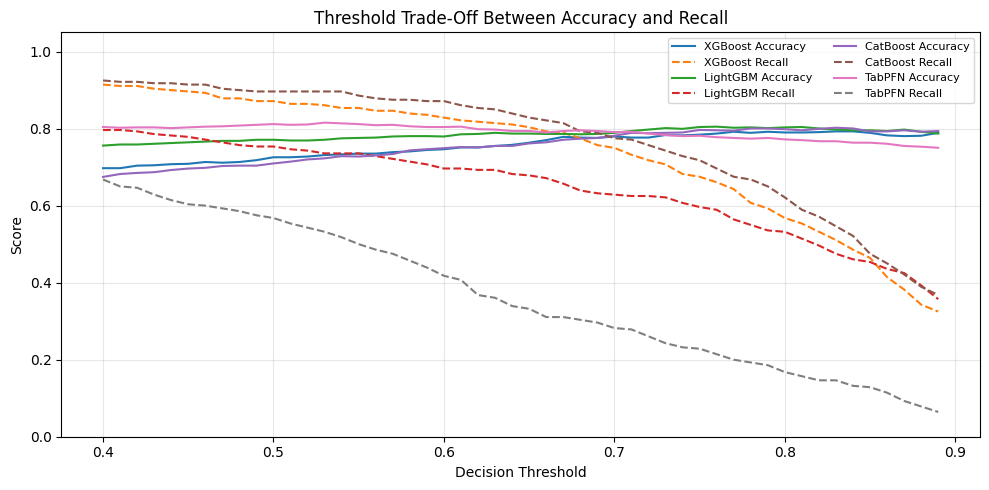

Saved: threshold_tradeoff_accuracy_recall.png


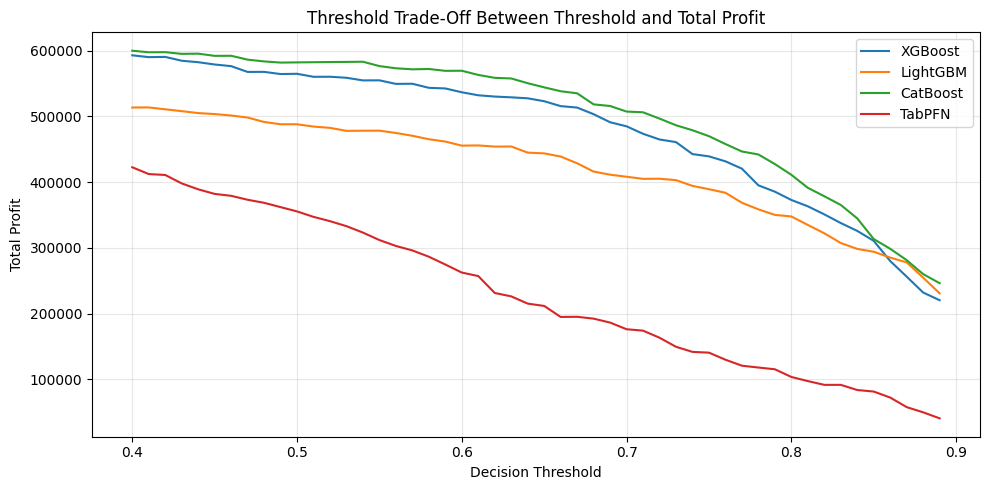

Saved: threshold_tradeoff_profit.png


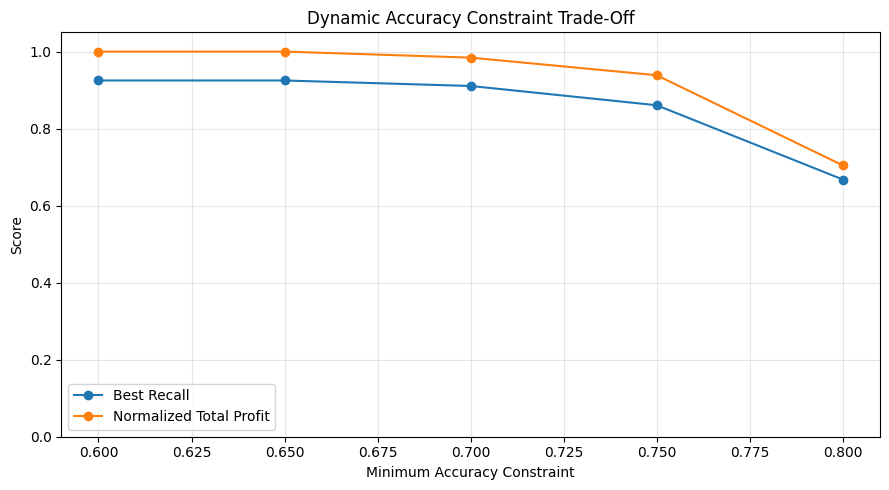

Saved: dynamic_accuracy_constraint_tradeoff.png


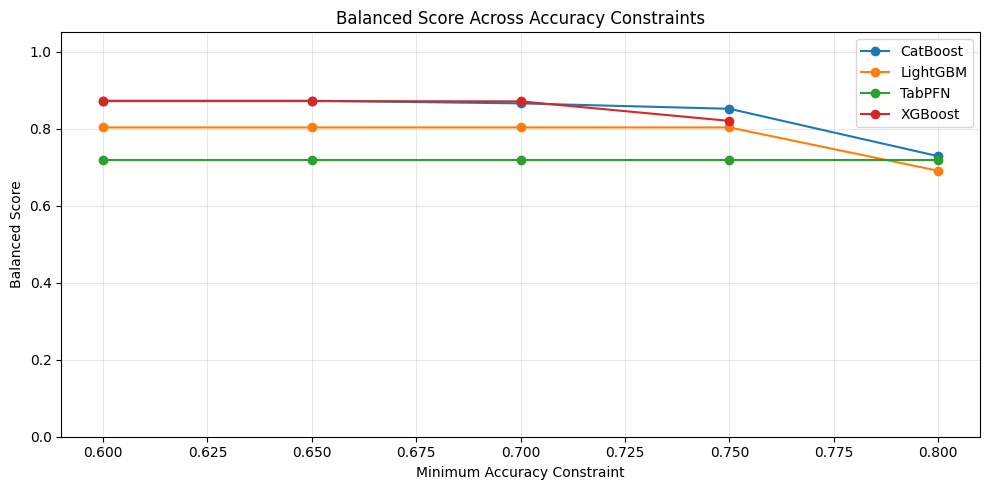

Saved: dynamic_balanced_score_by_constraint.png


In [64]:
# Cell 64 — Plot and save threshold and dynamic accuracy trade-off curves

# Plot 1: Threshold vs Accuracy and Recall
plt.figure(figsize=(10, 5))

for model_name in threshold_tradeoff_df["Model"].unique():
    temp_df = threshold_tradeoff_df[threshold_tradeoff_df["Model"] == model_name]

    plt.plot(
        temp_df["Threshold"],
        temp_df["Accuracy"],
        linestyle="-",
        label=f"{model_name} Accuracy"
    )

    plt.plot(
        temp_df["Threshold"],
        temp_df["Recall"],
        linestyle="--",
        label=f"{model_name} Recall"
    )

plt.title("Threshold Trade-Off Between Accuracy and Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/threshold_tradeoff_accuracy_recall.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved: threshold_tradeoff_accuracy_recall.png")


# Plot 2: Threshold vs Total Profit
plt.figure(figsize=(10, 5))

for model_name in threshold_tradeoff_df["Model"].unique():
    temp_df = threshold_tradeoff_df[threshold_tradeoff_df["Model"] == model_name]

    plt.plot(
        temp_df["Threshold"],
        temp_df["Total_Profit"],
        label=model_name
    )

plt.title("Threshold Trade-Off Between Threshold and Total Profit")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Profit")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/threshold_tradeoff_profit.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved: threshold_tradeoff_profit.png")


# Plot 3: Dynamic accuracy constraint trade-off
plot_dynamic_df = dynamic_accuracy_constraint_df[
    dynamic_accuracy_constraint_df["Status"] == "Achieved"
].copy()

plt.figure(figsize=(9, 5))

plt.plot(
    plot_dynamic_df["Accuracy_Constraint"],
    plot_dynamic_df["Recall"],
    marker="o",
    label="Best Recall"
)

plt.plot(
    plot_dynamic_df["Accuracy_Constraint"],
    plot_dynamic_df["Total_Profit"] / plot_dynamic_df["Total_Profit"].max(),
    marker="o",
    label="Normalized Total Profit"
)

plt.title("Dynamic Accuracy Constraint Trade-Off")
plt.xlabel("Minimum Accuracy Constraint")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/dynamic_accuracy_constraint_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved: dynamic_accuracy_constraint_tradeoff.png")

# Plot 4: Balanced score under multiple accuracy constraints

plot_balanced_df = balanced_constraint_df.copy()

plt.figure(figsize=(10, 5))

for model_name in plot_balanced_df["Model"].unique():
    temp_df = plot_balanced_df[plot_balanced_df["Model"] == model_name]

    plt.plot(
        temp_df["Accuracy_Constraint"],
        temp_df["Balanced_Score"],
        marker="o",
        label=model_name
    )

plt.title("Balanced Score Across Accuracy Constraints")
plt.xlabel("Minimum Accuracy Constraint")
plt.ylabel("Balanced Score")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/dynamic_balanced_score_by_constraint.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved: dynamic_balanced_score_by_constraint.png")

In [65]:
# Cell 65 — Single customer prediction function

def engineer_single_customer_features(customer_df):
    """
    Apply the same feature engineering to a single customer dataframe.
    """
    df_single = customer_df.copy()

    df_single["TenureGroup"] = pd.cut(
        df_single["Tenure Months"],
        bins=[-1, 12, 36, np.inf],
        labels=["New", "Mid", "Long"]
    ).astype(str)

    df_single["AvgSpendRatio"] = df_single["Total Charges"] / (df_single["Tenure Months"] + 1)

    service_cols_single = [
        "Phone Service",
        "Multiple Lines",
        "Online Security",
        "Online Backup",
        "Device Protection",
        "Tech Support",
        "Streaming TV",
        "Streaming Movies"
    ]

    existing_service_cols_single = [
        col for col in service_cols_single
        if col in df_single.columns
    ]

    df_single["ServiceCount"] = df_single[existing_service_cols_single].apply(
        lambda row: (row.astype(str).str.lower() == "yes").sum(),
        axis=1
    )

    df_single["ContractRisk"] = (
        df_single["Contract"].astype(str) == "Month-to-month"
    ).astype(int)

    df_single["SupportRisk"] = (
        (df_single["Online Security"].astype(str) == "No") &
        (df_single["Tech Support"].astype(str) == "No")
    ).astype(int)

    df_single["AutoPayment"] = df_single["Payment Method"].astype(str).isin(
        ["Bank transfer (automatic)", "Credit card (automatic)"]
    ).astype(int)

    return df_single


def predict_single_customer(customer_input, model_name="CatBoost", threshold=None):
    """
    Predict churn probability, expected profit, and retention priority for one customer.
    """
    customer_df = pd.DataFrame([customer_input])

    # Match original input feature columns before engineering
    customer_df = customer_df[X_raw.columns.tolist()]

    customer_engineered = engineer_single_customer_features(customer_df)

    if model_name not in test_prob_dict.keys():
        raise ValueError(f"Unknown model name: {model_name}")

    if threshold is None:
        threshold = best_thresholds[model_name]

    if model_name == "XGBoost":
        customer_processed = tree_preprocessor.transform(customer_engineered)
        churn_prob = xgb_model.predict_proba(customer_processed)[:, 1][0]

    elif model_name == "LightGBM":
        customer_processed = tree_preprocessor.transform(customer_engineered)
        churn_prob = lgbm_model.predict_proba(customer_processed)[:, 1][0]

    elif model_name == "CatBoost":
        customer_cat = customer_engineered.copy()
        for col in categorical_cols:
            customer_cat[col] = customer_cat[col].astype(str)

        churn_prob = cat_model.predict_proba(customer_cat)[:, 1][0]

    elif model_name == "TabPFN":
        customer_processed = tabpfn_preprocessor.transform(customer_engineered)
        churn_prob = tabpfn_model.predict_proba(customer_processed)[:, 1][0]

    cltv_value = float(customer_engineered["CLTV"].iloc[0])

    expected_profit = (churn_prob * cltv_value * retention_rate) - campaign_cost

    predicted_churn = int(churn_prob >= threshold)

    if expected_profit > 0 and churn_prob >= 0.70:
        priority = "High"
    elif expected_profit > 0 and churn_prob >= 0.40:
        priority = "Medium"
    else:
        priority = "Low"

    if priority == "High":
        recommended_action = "Immediate personalized retention offer and support follow-up"
    elif priority == "Medium":
        recommended_action = "Monitor customer and provide targeted retention offer"
    else:
        recommended_action = "No urgent retention action required"

    output = {
        "Model": model_name,
        "Threshold": threshold,
        "Churn_Probability": churn_prob,
        "Predicted_Churn": predicted_churn,
        "CLTV": cltv_value,
        "Expected_Profit": expected_profit,
        "Retention_Priority": priority,
        "Recommended_Action": recommended_action
    }

    return output

In [66]:
# Cell 66 — Example single customer prediction

example_customer = {
    "City": "Los Angeles",
    "Gender": "Female",
    "Senior Citizen": "No",
    "Partner": "No",
    "Dependents": "No",
    "Tenure Months": 6,
    "Phone Service": "Yes",
    "Multiple Lines": "No",
    "Internet Service": "Fiber optic",
    "Online Security": "No",
    "Online Backup": "No",
    "Device Protection": "No",
    "Tech Support": "No",
    "Streaming TV": "Yes",
    "Streaming Movies": "Yes",
    "Contract": "Month-to-month",
    "Paperless Billing": "Yes",
    "Payment Method": "Electronic check",
    "Monthly Charges": 95.50,
    "Total Charges": 573.00,
    "CLTV": 5200
}

single_prediction = predict_single_customer(
    example_customer,
    model_name="CatBoost"
)

display(pd.DataFrame([single_prediction]))

,Model,Threshold,Churn_Probability,Predicted_Churn,CLTV,Expected_Profit,Retention_Priority,Recommended_Action
0,CatBoost,0.4,0.960291,1,5200.0,2946.107657,High,Immediate personalized retention offer and sup...


In [67]:
# Cell 67 — Manual user input prediction using final selected model

def get_customer_input_from_user():
    """
    Collect customer information manually from notebook input prompts.
    """
    customer = {}

    print("Enter customer information below.\n")

    customer["City"] = input("City: ")
    customer["Gender"] = input("Gender (Male/Female): ")
    customer["Senior Citizen"] = input("Senior Citizen (Yes/No): ")
    customer["Partner"] = input("Partner (Yes/No): ")
    customer["Dependents"] = input("Dependents (Yes/No): ")

    customer["Tenure Months"] = int(input("Tenure Months: "))

    customer["Phone Service"] = input("Phone Service (Yes/No): ")
    customer["Multiple Lines"] = input("Multiple Lines (Yes/No/No phone service): ")
    customer["Internet Service"] = input("Internet Service (DSL/Fiber optic/No): ")

    customer["Online Security"] = input("Online Security (Yes/No/No internet service): ")
    customer["Online Backup"] = input("Online Backup (Yes/No/No internet service): ")
    customer["Device Protection"] = input("Device Protection (Yes/No/No internet service): ")
    customer["Tech Support"] = input("Tech Support (Yes/No/No internet service): ")

    customer["Streaming TV"] = input("Streaming TV (Yes/No/No internet service): ")
    customer["Streaming Movies"] = input("Streaming Movies (Yes/No/No internet service): ")

    customer["Contract"] = input("Contract (Month-to-month/One year/Two year): ")
    customer["Paperless Billing"] = input("Paperless Billing (Yes/No): ")
    customer["Payment Method"] = input(
        "Payment Method (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)): "
    )

    customer["Monthly Charges"] = float(input("Monthly Charges: "))
    customer["Total Charges"] = float(input("Total Charges: "))
    customer["CLTV"] = float(input("CLTV: "))

    return customer


# Final selected model under the base profit-optimized setting
selected_model = "CatBoost"

user_customer = get_customer_input_from_user()

user_prediction = predict_single_customer(
    user_customer,
    model_name=selected_model
)

display(pd.DataFrame([user_prediction]))

Enter customer information below.

City: Los Angeles
Gender (Male/Female): Female
Senior Citizen (Yes/No): No
Partner (Yes/No): No
Dependents (Yes/No): No
Tenure Months: 12
Phone Service (Yes/No): Yes
Multiple Lines (Yes/No/No phone service): No
Internet Service (DSL/Fiber optic/No): DSL
Online Security (Yes/No/No internet service): Yes
Online Backup (Yes/No/No internet service): No
Device Protection (Yes/No/No internet service): Yes
Tech Support (Yes/No/No internet service): Yes
Streaming TV (Yes/No/No internet service): No
Streaming Movies (Yes/No/No internet service): No
Contract (Month-to-month/One year/Two year): One year
Paperless Billing (Yes/No): Yes
Payment Method (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)): Electronic check
Monthly Charges: 95.00
Total Charges: 490
CLTV: 1200


,Model,Threshold,Churn_Probability,Predicted_Churn,CLTV,Expected_Profit,Retention_Priority,Recommended_Action
0,CatBoost,0.4,0.241217,0,1200.0,123.676178,Low,No urgent retention action required


In [68]:
# Cell 68 — Save additional task outputs

# Cross-validation outputs
cv_results_df.to_csv(f"{OUTPUT_DIR}/ten_fold_cv_results.csv", index=False)
cv_summary_df.to_csv(f"{OUTPUT_DIR}/ten_fold_cv_summary.csv", index=False)

# Threshold and dynamic constraint outputs
accuracy_threshold_df.to_csv(
    f"{OUTPUT_DIR}/accuracy_optimized_threshold_results.csv",
    index=False
)

threshold_tradeoff_df.to_csv(
    f"{OUTPUT_DIR}/threshold_tradeoff_results.csv",
    index=False
)

dynamic_accuracy_constraint_df.to_csv(
    f"{OUTPUT_DIR}/dynamic_accuracy_constraint_results.csv",
    index=False
)

perfect_recall_feasibility_df.to_csv(
    f"{OUTPUT_DIR}/perfect_recall_dynamic_accuracy_feasibility.csv",
    index=False
)

modelwise_accuracy_constraint_df.to_csv(
    f"{OUTPUT_DIR}/modelwise_accuracy_constraint_results.csv",
    index=False
)

balanced_constraint_df.to_csv(
    f"{OUTPUT_DIR}/dynamic_balanced_constraint_results.csv",
    index=False
)

pd.DataFrame([best_dynamic_balanced_row]).to_csv(
    f"{OUTPUT_DIR}/best_dynamic_balanced_result.csv",
    index=False
)

strategy_compare_df.to_csv(
    f"{OUTPUT_DIR}/threshold_strategy_comparison.csv",
    index=False
)

# SMOTE benefit output
smote_benefit_df.to_csv(
    f"{OUTPUT_DIR}/smote_benefit_comparison.csv",
    index=False
)

# Save example prediction output
single_prediction_df = pd.DataFrame([single_prediction])
single_prediction_df.to_csv(
    f"{OUTPUT_DIR}/single_customer_prediction_example.csv",
    index=False
)

# Save manual input prediction output if available
try:
    user_prediction_df = pd.DataFrame([user_prediction])
    user_prediction_df.to_csv(
        f"{OUTPUT_DIR}/manual_user_input_prediction.csv",
        index=False
    )
except NameError:
    print("Manual user prediction was not available, so it was not saved.")

print("Additional task outputs saved.")

Additional task outputs saved.


In [69]:
# Cell 69 — Summarize final objective-based model recommendations

profit_best_row = final_results_df.iloc[0]

accuracy_best_row = accuracy_threshold_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

dynamic_best_row = best_dynamic_balanced_row

print("Final Objective-Based Model Recommendations")
print("=" * 70)

print("\n1. Profit-Maximizing Broad Retention Model")
print("-" * 70)
print("Model:", profit_best_row["Model"])
print("Threshold:", round(profit_best_row["Best_Threshold"], 3))
print("Accuracy:", round(profit_best_row["Accuracy"], 4))
print("Recall:", round(profit_best_row["Recall"], 4))
print("Total Profit:", round(profit_best_row["Total_Profit"], 2))
print("CLTV Weighted Recall:", round(profit_best_row["CLTV_Weighted_Recall"], 4))

print("\n2. Highest Leakage-Safe Accuracy Model")
print("-" * 70)
print("Model:", accuracy_best_row["Model"])
print("Threshold:", round(accuracy_best_row["Accuracy_Optimized_Threshold"], 3))
print("Accuracy:", round(accuracy_best_row["Accuracy"], 4))
print("Recall:", round(accuracy_best_row["Recall"], 4))
print("Total Profit:", round(accuracy_best_row["Total_Profit"], 2))

print("\n3. Dynamic Accuracy-Constrained Balanced Model")
print("-" * 70)
print("Model:", dynamic_best_row["Model"])
print("Accuracy Constraint:", round(dynamic_best_row["Accuracy_Constraint"], 2))
print("Threshold:", round(dynamic_best_row["Threshold"], 3))
print("Accuracy:", round(dynamic_best_row["Accuracy"], 4))
print("Recall:", round(dynamic_best_row["Recall"], 4))
print("F1-score:", round(dynamic_best_row["F1"], 4))
print("Total Profit:", round(dynamic_best_row["Total_Profit"], 2))
print("Balanced Score:", round(dynamic_best_row["Balanced_Score"], 4))

Final Objective-Based Model Recommendations

1. Profit-Maximizing Broad Retention Model
----------------------------------------------------------------------
Model: CatBoost
Threshold: 0.4
Accuracy: 0.6746
Recall: 0.925
Total Profit: 599968.8
CLTV Weighted Recall: 0.9261

2. Highest Leakage-Safe Accuracy Model
----------------------------------------------------------------------
Model: TabPFN
Threshold: 0.53
Accuracy: 0.8155
Recall: 0.5321
Total Profit: 333159.6

3. Dynamic Accuracy-Constrained Balanced Model
----------------------------------------------------------------------
Model: CatBoost
Accuracy Constraint: 0.6
Threshold: 0.4
Accuracy: 0.6746
Recall: 0.925
F1-score: 0.6009
Total Profit: 599968.8
Balanced Score: 0.8724


In [70]:
# Cell 70 — Generate final project conclusion

profit_best_model = final_results_df.iloc[0]["Model"]

best_accuracy_row = accuracy_threshold_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

dynamic_best_row = best_dynamic_balanced_row

conclusion = f"""
Final Project Conclusion

This implementation developed a profit-aware, fairness-aware, and explainable telco customer churn prediction framework using XGBoost, LightGBM, CatBoost, and TabPFN.

Under the base profit-optimized setting, the best model was {profit_best_model}. This model was selected because it achieved the highest total profit under the validation-optimized threshold strategy. This result supports broad retention targeting when campaign cost is low and capturing churned customers is the main priority.

The 10-fold cross-validation analysis was used to evaluate model stability across folds. This provided an additional validation layer beyond the fixed train-validation-test split.

The accuracy-focused threshold analysis showed that the highest leakage-safe accuracy was achieved by {best_accuracy_row["Model"]}, with an accuracy of {best_accuracy_row["Accuracy"]:.4f} at threshold {best_accuracy_row["Accuracy_Optimized_Threshold"]:.2f}. This confirms that higher accuracy was not forced using leakage-prone features.

Instead of using a fixed 70% accuracy constraint, the dynamic accuracy constraint analysis tested several minimum accuracy requirements from 60% to 85%. For each accuracy constraint and each model, the threshold that maximized recall was identified. A balanced score combining recall, accuracy, and normalized profit was then used to select the most practical accuracy-constrained deployment option.

Under the dynamic balanced strategy, the selected model was {dynamic_best_row["Model"]}, with an accuracy constraint of {dynamic_best_row["Accuracy_Constraint"]:.2f}, threshold {dynamic_best_row["Threshold"]:.2f}, accuracy {dynamic_best_row["Accuracy"]:.4f}, recall {dynamic_best_row["Recall"]:.4f}, total profit {dynamic_best_row["Total_Profit"]:.2f}, and balanced score {dynamic_best_row["Balanced_Score"]:.4f}.

The perfect-recall feasibility analysis showed whether 100% recall could be maintained under different accuracy constraints. This analysis explains the trade-off between capturing all churned customers and maintaining higher classification accuracy.

SMOTE was also compared against the original XGBoost and LightGBM models. The SMOTE comparison showed whether synthetic oversampling improved conventional classification metrics, while the profit and CLTV-recall comparison showed whether it was useful for the business objective.

Overall, the final system does not depend on a single fixed metric or a single arbitrary accuracy threshold. CatBoost is most suitable for maximum-profit broad retention campaigns, while the dynamic balanced strategy provides a systematic way to select an accuracy-constrained deployment option. The framework also supports customer-level retention priority generation, churn reason interpretation, fairness analysis, explainability, and single-customer prediction.
"""

print(conclusion)


Final Project Conclusion

This implementation developed a profit-aware, fairness-aware, and explainable telco customer churn prediction framework using XGBoost, LightGBM, CatBoost, and TabPFN.

Under the base profit-optimized setting, the best model was CatBoost. This model was selected because it achieved the highest total profit under the validation-optimized threshold strategy. This result supports broad retention targeting when campaign cost is low and capturing churned customers is the main priority.

The 10-fold cross-validation analysis was used to evaluate model stability across folds. This provided an additional validation layer beyond the fixed train-validation-test split.

The accuracy-focused threshold analysis showed that the highest leakage-safe accuracy was achieved by TabPFN, with an accuracy of 0.8155 at threshold 0.53. This confirms that higher accuracy was not forced using leakage-prone features.

Instead of using a fixed 70% accuracy constraint, the dynamic accurac

In [71]:
# Cell 71 — Check saved result files and figures
print("Saved CSV/result files:")
for file_name in sorted(os.listdir(OUTPUT_DIR)):
    if file_name.endswith(".csv"):
        print(file_name)

print("\nSaved figures:")
for file_name in sorted(os.listdir(FIGURE_DIR)):
    print(file_name)

Saved CSV/result files:
accuracy_optimized_threshold_results.csv
best_dynamic_balanced_result.csv
best_model_by_business_scenario.csv
default_classification_results.csv
default_profit_results.csv
dynamic_accuracy_constraint_results.csv
dynamic_balanced_constraint_results.csv
fairness_results.csv
final_combined_results.csv
manual_user_input_prediction.csv
modelwise_accuracy_constraint_results.csv
optimized_classification_results.csv
optimized_profit_results.csv
perfect_recall_dynamic_accuracy_feasibility.csv
profit_sensitivity_results.csv
retention_priority_list.csv
single_customer_prediction_example.csv
smote_benefit_comparison.csv
smote_comparison_results.csv
tabpfn_permutation_importance.csv
ten_fold_cv_results.csv
ten_fold_cv_summary.csv
threshold_strategy_comparison.csv
threshold_tradeoff_results.csv

Saved figures:
catboost_shap_summary.png
classification_performance_comparison.png
cross_validation_model_comparison.png
dynamic_accuracy_constraint_tradeoff.png
dynamic_balanced_scor

In [73]:
# Cell 72 — Save Final Model + Full Project Results as PKL

import pickle
import os
import glob

os.makedirs(OUTPUT_DIR, exist_ok=True)

def get_var(name, default=None):
    return globals()[name] if name in globals() else default

def row_to_dict(row):
    try:
        return row.to_dict()
    except:
        return row

# ===============================
# 1. FINAL MODEL PACKAGE
# ===============================

final_model_package = {
    "project_name": "Telco Customer Churn Prediction",
    "selected_model_name": "CatBoost",
    "model": cat_model,
    "best_threshold": best_thresholds.get("CatBoost", 0.40),
    "feature_columns": X.columns.tolist(),
    "raw_input_columns": X_raw.columns.tolist(),
    "categorical_cols": categorical_cols,
    "numerical_cols": numerical_cols,
    "cat_features_indices": cat_features_indices,
    "target_col": target_col,
    "retention_rate": retention_rate,
    "campaign_cost": campaign_cost
}

with open(f"{OUTPUT_DIR}/final_model.pkl", "wb") as f:
    pickle.dump(final_model_package, f)

print("Final model package saved:")
print(f"{OUTPUT_DIR}/final_model.pkl")


# ===============================
# 2. FULL PROJECT RESULTS PACKAGE
# ===============================

full_project_results = {
    "project_name": "Telco Customer Churn Prediction",

    "final_conclusion": get_var("conclusion"),

    "final_recommendations": {
        "profit_best_row": row_to_dict(get_var("profit_best_row")),
        "accuracy_best_row": row_to_dict(get_var("accuracy_best_row")),
        "dynamic_best_row": row_to_dict(get_var("dynamic_best_row")),
        "best_dynamic_balanced_row": row_to_dict(get_var("best_dynamic_balanced_row"))
    },

    "model_names": list(test_prob_dict.keys()),

    "thresholds": {
        "best_thresholds": get_var("best_thresholds"),
        "validation_profit_curves": get_var("validation_profit_curves")
    },

    "classification_and_profit_results": {
        "default_results_df": get_var("default_results_df"),
        "default_profit_df": get_var("default_profit_df"),
        "optimized_classification_df": get_var("optimized_classification_df"),
        "optimized_profit_df": get_var("optimized_profit_df"),
        "final_results_df": get_var("final_results_df")
    },

    "cross_validation_results": {
        "cv_results_df": get_var("cv_results_df"),
        "cv_summary_df": get_var("cv_summary_df")
    },

    "fairness_results": {
        "fairness_results_df": get_var("fairness_results_df"),
        "final_results_with_fairness": get_var("final_results_with_fairness")
    },

    "smote_results": {
        "smote_results_df": get_var("smote_results_df"),
        "smote_benefit_df": get_var("smote_benefit_df")
    },

    "threshold_analysis": {
        "accuracy_threshold_df": get_var("accuracy_threshold_df"),
        "threshold_tradeoff_df": get_var("threshold_tradeoff_df"),
        "dynamic_accuracy_constraint_df": get_var("dynamic_accuracy_constraint_df"),
        "perfect_recall_feasibility_df": get_var("perfect_recall_feasibility_df"),
        "modelwise_accuracy_constraint_df": get_var("modelwise_accuracy_constraint_df"),
        "balanced_constraint_df": get_var("balanced_constraint_df"),
        "strategy_compare_df": get_var("strategy_compare_df")
    },

    "business_outputs": {
        "priority_df": get_var("priority_df"),
        "top_churn_reasons": get_var("top_churn_reasons"),
        "top_high_priority_reasons": get_var("top_high_priority_reasons"),
        "retention_actions": get_var("retention_actions"),
        "single_prediction": get_var("single_prediction"),
        "user_prediction": get_var("user_prediction")
    },

    "explainability": {
        "tabpfn_importance_df": get_var("tabpfn_importance_df"),
        "xgb_shap_values_saved": "SHAP plot saved as image",
        "lgbm_shap_values_saved": "SHAP plot saved as image",
        "cat_shap_values_saved": "SHAP plot saved as image"
    },

    "probabilities": {
        "val_prob_dict": get_var("val_prob_dict"),
        "test_prob_dict": get_var("test_prob_dict")
    },

    "data_samples": {
        "X_test": get_var("X_test"),
        "y_test": get_var("y_test"),
        "cltv_test": get_var("cltv_test"),
        "gender_test": get_var("gender_test"),
        "senior_test": get_var("senior_test"),
        "reason_test": get_var("reason_test")
    },

    "saved_files": {
        "output_dir": OUTPUT_DIR,
        "figure_dir": FIGURE_DIR,
        "csv_files": sorted(glob.glob(f"{OUTPUT_DIR}/*.csv")),
        "figure_files": sorted(glob.glob(f"{FIGURE_DIR}/*"))
    }
}

with open(f"{OUTPUT_DIR}/full_project_results.pkl", "wb") as f:
    pickle.dump(full_project_results, f)

print("\nFull project results package saved:")
print(f"{OUTPUT_DIR}/full_project_results.pkl")

print("\nPKL saving completed successfully.")

Final model package saved:
telco_churn_results/final_model.pkl

Full project results package saved:
telco_churn_results/full_project_results.pkl

PKL saving completed successfully.


In [74]:
# Cell 73 — Zip and download all result files

import shutil
from google.colab import files

ZIP_NAME = "telco_churn_results.zip"

shutil.make_archive(
    base_name="telco_churn_results",
    format="zip",
    root_dir=OUTPUT_DIR
)

print("ZIP file created:", ZIP_NAME)

files.download(ZIP_NAME)

ZIP file created: telco_churn_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>